# Data Mining

**Authors:** Group 10

Below is our approach to developing a customer business credit application prediction system for Universal Plus.

The original full dataset provided by the client included 100,000 records and 200 anonymised numerical variables denoted by “var_0”, “var_1”, …, “var_199”. Variable “ID_code” corresponds to the customer ID and “target” is the binary variable, taking the value 1 if the customer applied for business credit and 0 otherwise.

In [179]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score, RocCurveDisplay, make_scorer, PrecisionRecallDisplay, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb
from matplotlib.patches import FancyBboxPatch

In [2]:
# Load the dataset
datafile = pd.read_csv("datafile_full.csv")

# Display basic information
print(f"Data loaded: {datafile.shape[0]} rows, {datafile.shape[1]} columns")
datafile.head()

Data loaded: 100000 rows, 202 columns


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,125172.0,0,10.6216,0.1667,15.5182,10.1634,9.8419,-0.1156,7.4348,14.6948,...,2.8498,2.6391,1.2207,9.2747,22.3657,-0.4631,-3.1550,8.7551,15.9985,-10.4585
1,93976.0,0,13.1492,2.9210,6.0275,5.7623,12.5731,7.9090,5.3149,17.8441,...,9.1415,6.6176,2.6736,1.4019,17.5274,0.8023,-1.9248,7.5983,19.4170,-0.8740
2,128558.0,0,7.9077,4.3397,8.5575,4.7743,10.3623,-6.6784,5.9665,17.2378,...,6.9435,9.1727,0.2197,3.7017,17.7719,-0.8418,5.6689,9.1611,16.0874,-20.2895
3,138582.0,0,6.1757,-1.5021,16.5598,8.9091,8.0741,5.4070,5.3698,10.8735,...,5.6109,6.4601,0.6941,1.9114,19.0942,0.6026,8.6251,9.3223,14.9434,-13.8717
4,109242.0,0,10.6910,-6.5074,11.0558,4.4293,8.7645,-15.5975,5.6018,20.1398,...,-2.3920,11.2617,1.6179,11.2651,12.0931,-1.1808,7.2005,8.7301,14.8803,4.5960


In [3]:
# Check for duplicates 
number_of_dups = datafile.duplicated().sum()
if number_of_dups > 0:
    print(f"\nFound {n_dups} duplicate rows – removing them")
    datafile = datafile.drop_duplicates()
else:
    print("\nNo duplicate rows found")
print("Shape after duplicate removal:", datafile.shape)


No duplicate rows found
Shape after duplicate removal: (100000, 202)


In [4]:
# Remove ID_code column
datafile = datafile.drop(columns=['ID_code'])
print(f"Updated shape: {datafile.shape}")

Updated shape: (100000, 201)


In [5]:
# Check which columns have missing values
missing_counts = datafile.isnull().sum()
total_missing = missing_counts.sum()
print(f"Total missing values: {total_missing}")
print("\nColumns with missing values:")
print(missing_counts[missing_counts > 0].sort_values(ascending=False))

Total missing values: 50109

Columns with missing values:
var_45     40003
var_96      5004
var_76      5003
var_18         5
var_16         3
           ...  
var_22         1
var_94         1
var_19         1
var_17         1
var_185        1
Length: 71, dtype: int64


In [6]:
# Variables to check for outliers

# Decided to pick 10 variables (5%) of our varaibles with highest standard deviation
# (high std = wide spread = more likely to have outliers)
std_devs = {}
for col in datafile.columns:
    if col.startswith('var_'):
        std_devs[col] = datafile[col].std()
sorted_std = sorted(std_devs.items(), key=lambda x: x[1], reverse=True)
high_std_vars = [x[0] for x in sorted_std[:10]]
print("Top 10 variables with highest variation:")
for i, var in enumerate(high_std_vars, 1):
    print(f"  {i}. {var}: std = {datafile[var].std():.2f}")

Top 10 variables with highest variation:
  1. var_45: std = 21.38
  2. var_74: std = 14.17
  3. var_117: std = 13.35
  4. var_90: std = 13.16
  5. var_97: std = 12.64
  6. var_120: std = 12.13
  7. var_70: std = 11.96
  8. var_61: std = 11.61
  9. var_187: std = 11.55
  10. var_48: std = 11.37


In [7]:
# Check variables with missing data 
missing_vars = missing_counts[missing_counts > 0].index.tolist()
print(f"\nVariables with missing data: {len(missing_vars)}")
for var in missing_vars:
    pct = (missing_counts[var] / len(datafile)) * 100
    print(f"{var}: {pct:.1f}% missing")


Variables with missing data: 71
var_1: 0.0% missing
var_7: 0.0% missing
var_8: 0.0% missing
var_9: 0.0% missing
var_10: 0.0% missing
var_11: 0.0% missing
var_12: 0.0% missing
var_13: 0.0% missing
var_15: 0.0% missing
var_16: 0.0% missing
var_17: 0.0% missing
var_18: 0.0% missing
var_19: 0.0% missing
var_22: 0.0% missing
var_24: 0.0% missing
var_25: 0.0% missing
var_27: 0.0% missing
var_33: 0.0% missing
var_37: 0.0% missing
var_39: 0.0% missing
var_41: 0.0% missing
var_45: 40.0% missing
var_46: 0.0% missing
var_47: 0.0% missing
var_48: 0.0% missing
var_49: 0.0% missing
var_50: 0.0% missing
var_51: 0.0% missing
var_53: 0.0% missing
var_59: 0.0% missing
var_61: 0.0% missing
var_62: 0.0% missing
var_68: 0.0% missing
var_70: 0.0% missing
var_76: 5.0% missing
var_77: 0.0% missing
var_79: 0.0% missing
var_85: 0.0% missing
var_87: 0.0% missing
var_90: 0.0% missing
var_93: 0.0% missing
var_94: 0.0% missing
var_95: 0.0% missing
var_96: 5.0% missing
var_97: 0.0% missing
var_99: 0.0% missing
var_

In [8]:
# Summary stats for the selected variables
print("Summary statistics:\n")
for col in high_std_vars:
    print(f"{col}:")
    print(f"  Min:    {datafile[col].min():.2f}")
    print(f"  Max:    {datafile[col].max():.2f}")
    print(f"  Mean:   {datafile[col].mean():.2f}")
    print(f"  Median: {datafile[col].median():.2f}")
    print()

Summary statistics:

var_45:
  Min:    -82.13
  Max:    62.08
  Mean:   -12.69
  Median: -12.50

var_74:
  Min:    -34.10
  Max:    70.27
  Mean:   19.46
  Median: 19.50

var_117:
  Min:    -30.05
  Max:    64.81
  Mean:   16.05
  Median: 15.88

var_90:
  Min:    -61.72
  Max:    27.27
  Mean:   -16.53
  Median: -16.43

var_97:
  Min:    -21.74
  Max:    56.33
  Mean:   18.54
  Median: 18.52

var_120:
  Min:    -18.41
  Max:    74.03
  Mean:   24.52
  Median: 24.33

var_70:
  Min:    -15.93
  Max:    60.94
  Mean:   24.45
  Median: 24.47

var_61:
  Min:    -48.80
  Max:    26.90
  Mean:   -12.01
  Median: -12.00

var_187:
  Min:    -46.49
  Max:    21.75
  Mean:   -10.37
  Median: -10.25

var_48:
  Min:    -23.80
  Max:    53.73
  Mean:   14.67
  Median: 14.53



Boxplots for the 10 variables


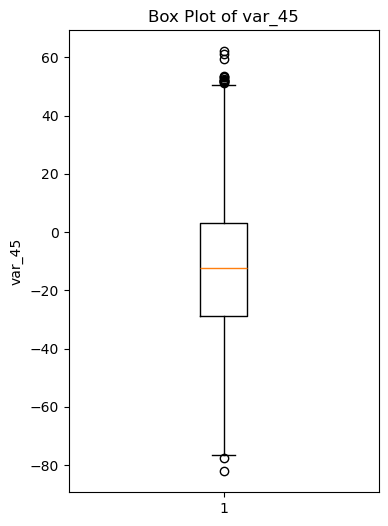

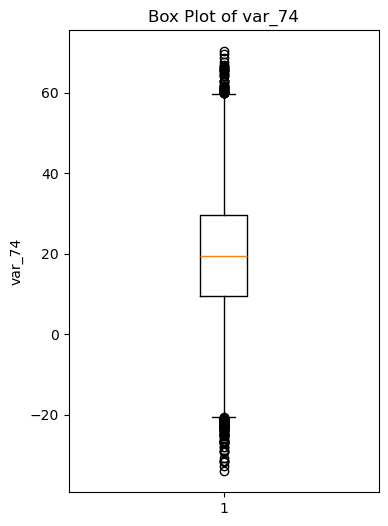

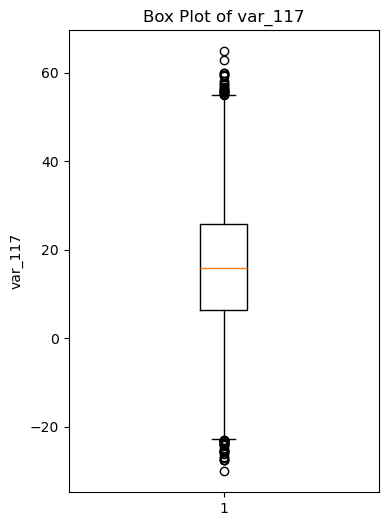

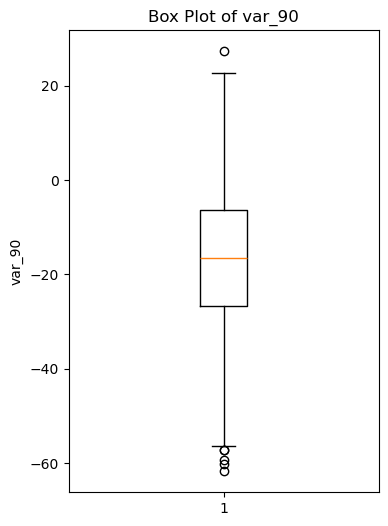

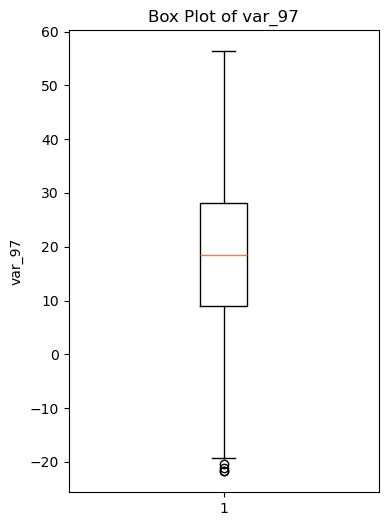

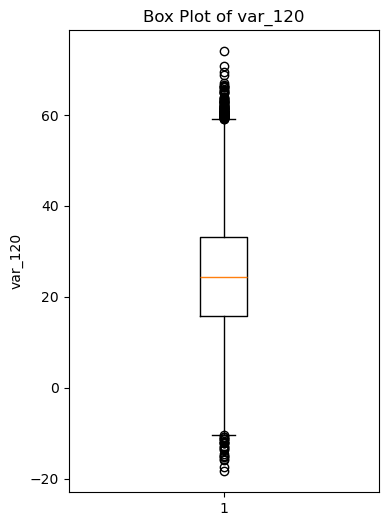

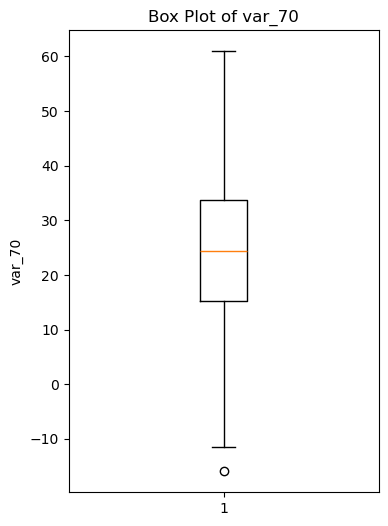

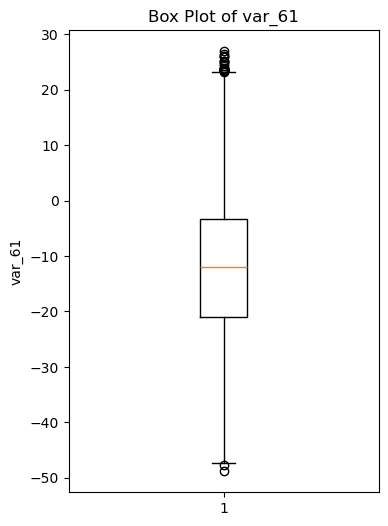

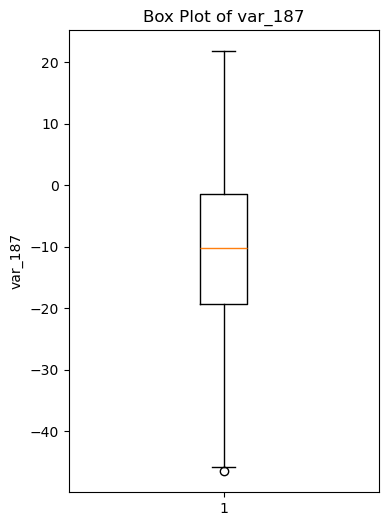

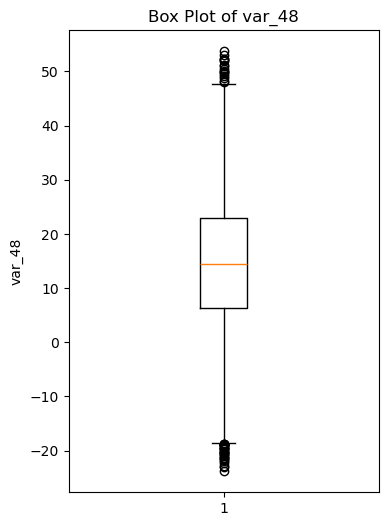

In [9]:
# Boxplots to visually inspect for outliers for our selected variables 
print(f"Boxplots for the {len(high_std_vars)} variables")
for col in high_std_vars:
    plt.figure(figsize=(4, 6))
    plt.boxplot(datafile[col].dropna())
    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)
    plt.show()

Creating histograms for 10 variables
Close each window to see the next one



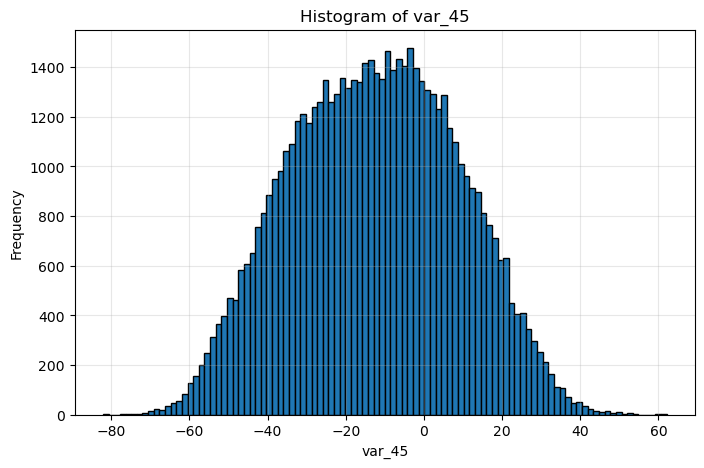

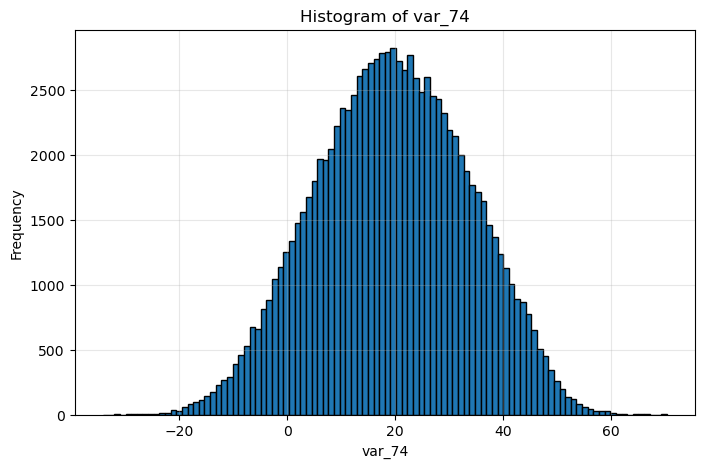

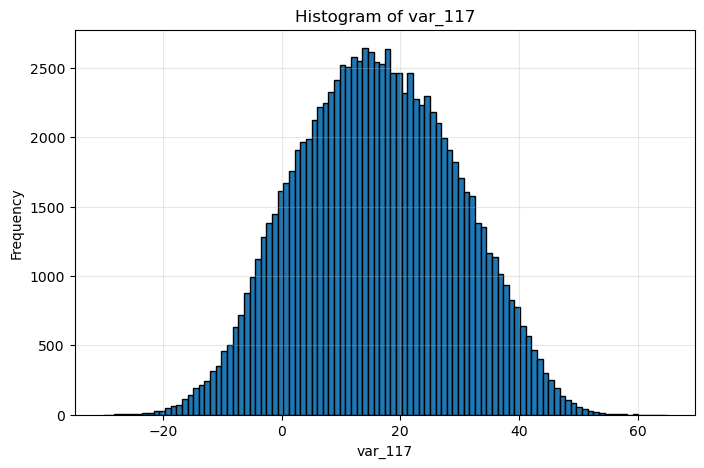

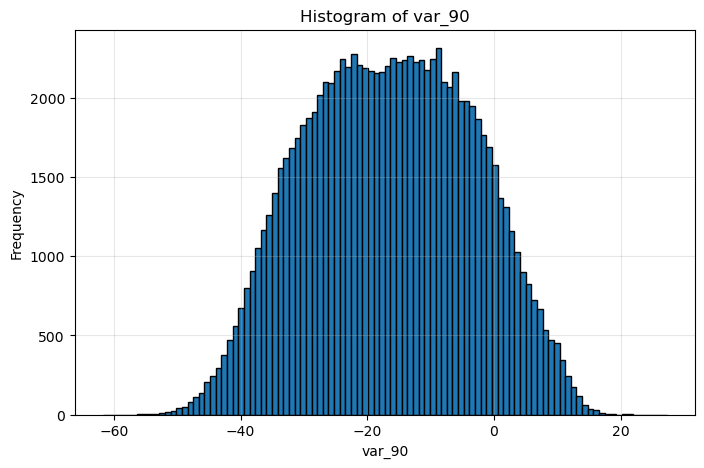

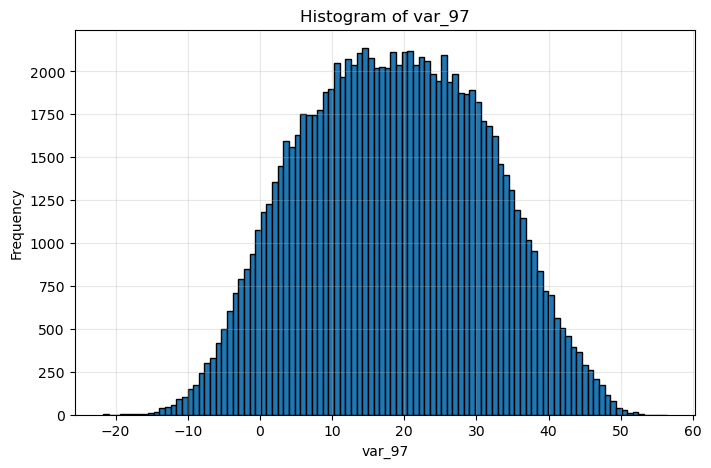

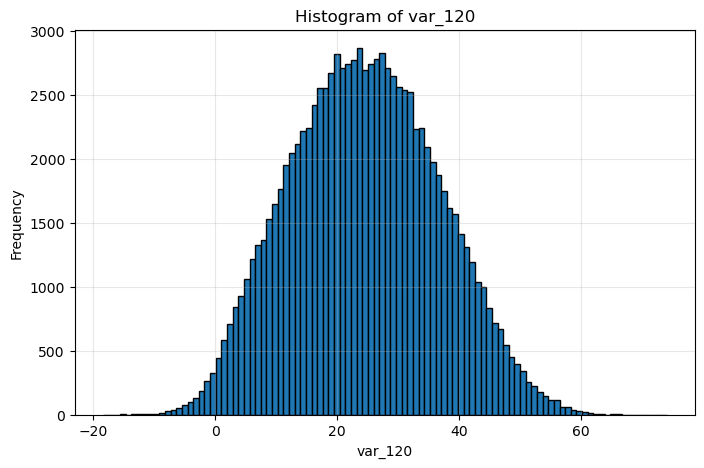

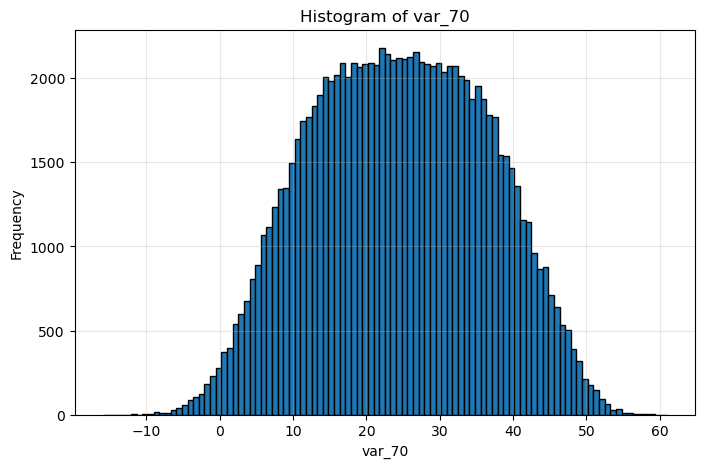

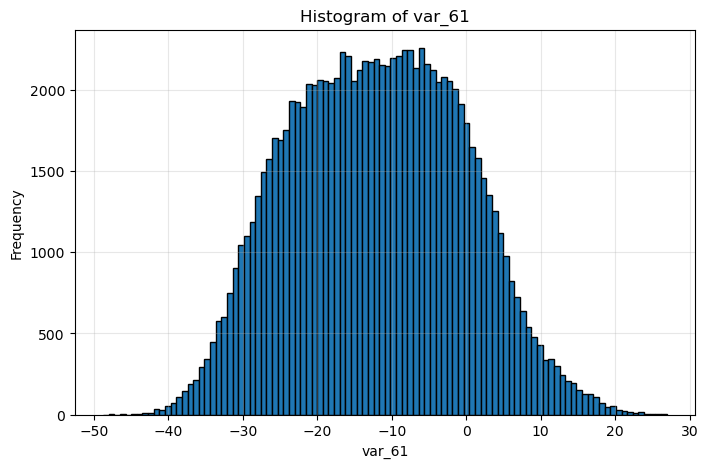

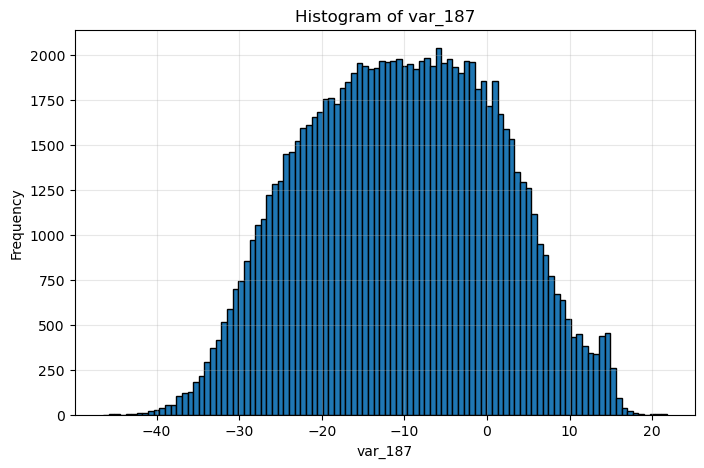

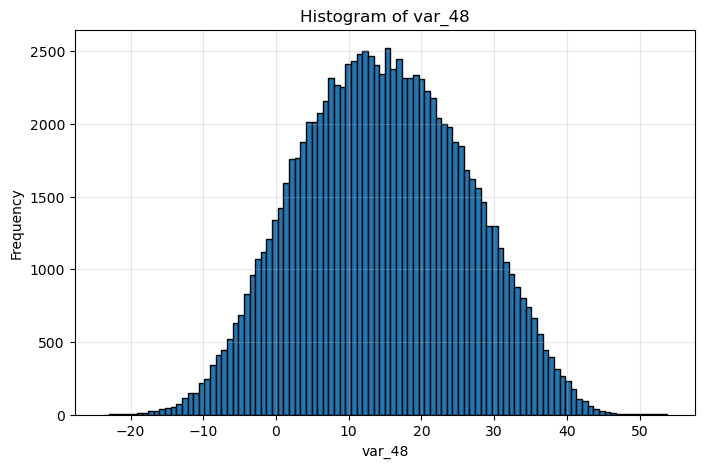

In [10]:
# Create histograms to see the distribution of values for our selected variables
print(f"Creating histograms for {len(high_std_vars)} variables")
print("Close each window to see the next one\n")
for col in high_std_vars:
    plt.figure(figsize=(8, 5))
    plt.hist(datafile[col].dropna(), bins=100, edgecolor='black')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.show()

In [11]:
# Based on visual inspection, keep outliers
print("Decision: keep all outliers")
print("\nReasons:")
print("1. Anonymized data - cannot determine what is 'wrong' vs 'unusual'")
print("2. Outliers might represent important rare cases (high-value customers)")
print("3. Severe class imbalance (90:10) - cannot afford to lose data")
print("4. Same dataset for all models ensures fair comparison")
print(f"\nRows retained: {datafile.shape[0]}")
print("All models will use the same cleaned dataset")

Decision: keep all outliers

Reasons:
1. Anonymized data - cannot determine what is 'wrong' vs 'unusual'
2. Outliers might represent important rare cases (high-value customers)
3. Severe class imbalance (90:10) - cannot afford to lose data
4. Same dataset for all models ensures fair comparison

Rows retained: 100000
All models will use the same cleaned dataset


In [12]:
# Created 2 different approaches to handle missing data in our dataset
# Pipeline A: Drop var_45 (the column with 40% missing data)
# Pipeline B: Keep var_45 and impute it with median + add missingness indicator

# Pipeline A - drop columns with high-missingness and impute rest with median
datafile_A = datafile.copy()
print("Creating Pipeline A: Drop high-missingness columns")

# Find columns with more than 10% missing data
high_missing_cols = []
for col in datafile.columns:
    if col.startswith('var_'):
        missing_pct = (datafile[col].isnull().sum() / len(datafile)) * 100
        if missing_pct > 10:
            high_missing_cols.append(col)
            print(f"Found: {col} with {missing_pct:.1f}% missing")
print(f"\nTotal columns to drop: {len(high_missing_cols)}")

# Drop these high-missingness columns from Pipeline A
datafile_A = datafile_A.drop(columns=high_missing_cols)
print(f"Pipeline A shape after dropping: {datafile_A.shape}")
print(f"Dropped columns: {high_missing_cols}")

# Impute the remaining missing values in Pipeline A with median
for col in datafile_A.columns:
    if col.startswith('var_') and datafile_A[col].isnull().sum() > 0:
        median_value = datafile_A[col].median()
        missing_count = datafile_A[col].isnull().sum()
        datafile_A[col] = datafile_A[col].fillna(median_value)
print(f"\nPipeline A final shape: {datafile_A.shape}")
print("All rows retained, only var_45 column was dropped")


# Pipeline B - keep all data and impute with median
datafile_B = datafile.copy()
print("Impute all missing values with median\n")
for col in datafile_B.columns:
    if col.startswith('var_') and datafile_B[col].isnull().sum() > 0:
        missing_count = datafile_B[col].isnull().sum()
        median_value = datafile_B[col].median()
        datafile_B[col] = datafile_B[col].fillna(median_value)
print(f"\nPipeline B final shape: {datafile_B.shape}")
print("All rows retained, all missing values imputed with median")

Creating Pipeline A: Drop high-missingness columns
Found: var_45 with 40.0% missing

Total columns to drop: 1
Pipeline A shape after dropping: (100000, 200)
Dropped columns: ['var_45']

Pipeline A final shape: (100000, 200)
All rows retained, only var_45 column was dropped
Impute all missing values with median


Pipeline B final shape: (100000, 201)
All rows retained, all missing values imputed with median


In [13]:
# Separate features and target for both pipelines

# Pipeline A
X_A = datafile_A.drop("target", axis=1)
y_A = datafile_A["target"]
print("Pipeline A:")
print(f"Features: {X_A.shape}")
print(f"Target:   {y_A.shape}")

# Pipeline B
X_B = datafile_B.drop("target", axis=1)
y_B = datafile_B["target"]
print("\nPipeline B:")
print(f"Features: {X_B.shape}")
print(f"Target:   {y_B.shape}")

Pipeline A:
Features: (100000, 199)
Target:   (100000,)

Pipeline B:
Features: (100000, 200)
Target:   (100000,)


In [14]:
# Check target distribution and calculate imbalance ratio

# Pipeline A
print("Target distribution:")
print(y_A.value_counts())
print("\nProportions:")
print(y_A.value_counts(normalize=True))

# Calculate imbalance ratio for Pipeline A
value_counts = y_A.value_counts()
imbalance_ratio = value_counts.min() / value_counts.max()
print(f"\nImbalance ratio pipeine A: {imbalance_ratio:.4f}")

# Pipeline B
print("Target distribution:")
print(y_B.value_counts())
print("\nProportions:")
print(y_B.value_counts(normalize=True))

# Calculate imbalance ratio for Pipeline B
value_counts = y_B.value_counts()
imbalance_ratio = value_counts.min() / value_counts.max()
print(f"\nImbalance ratio pipeline B: {imbalance_ratio:.4f}")

Target distribution:
target
0    89962
1    10038
Name: count, dtype: int64

Proportions:
target
0    0.89962
1    0.10038
Name: proportion, dtype: float64

Imbalance ratio pipeine A: 0.1116
Target distribution:
target
0    89962
1    10038
Name: count, dtype: int64

Proportions:
target
0    0.89962
1    0.10038
Name: proportion, dtype: float64

Imbalance ratio pipeline B: 0.1116


In [15]:
# Partitioning training and testing data 

# Set random seed 
random_seed = 42

# Pipeline A
X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(
    X_A,                      
    y_A,                      
    test_size=0.2,            
    random_state=random_seed,
    stratify=y_A             
)
print("\nPipeline A split:")
print(f"Train set: {X_A_train.shape[0]} rows, {X_A_train.shape[1]} features")
print(f"Test set:  {X_A_test.shape[0]} rows")
print(f"Train target distribution:")
print(y_A_train.value_counts())

# Pipeline B
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B,
    y_B,
    test_size=0.2,
    random_state=random_seed,
    stratify=y_B
)
print("\nPipeline B split:")
print(f"Train set: {X_B_train.shape[0]} rows, {X_B_train.shape[1]} features")
print(f"Test set:  {X_B_test.shape[0]} rows")
print(f"Train target distribution:")
print(y_B_train.value_counts())


Pipeline A split:
Train set: 80000 rows, 199 features
Test set:  20000 rows
Train target distribution:
target
0    71970
1     8030
Name: count, dtype: int64

Pipeline B split:
Train set: 80000 rows, 200 features
Test set:  20000 rows
Train target distribution:
target
0    71970
1     8030
Name: count, dtype: int64


In [16]:
# Calculate Information Gain for variables

# Pipeline A
ig_scores_A = mutual_info_classif(X_A_train, y_A_train, random_state=random_seed)

# Display top 10 features for Pipeline A
print("\nPipeline A - Top 10 features by Information Gain:")
feature_names_A = X_A_train.columns
top_10_indices_A = np.argsort(ig_scores_A)[-10:][::-1]
for i, idx in enumerate(top_10_indices_A, 1):
    print(f"{i}. {feature_names_A[idx]}: {ig_scores_A[idx]:.4f}")

# Pipeline B
ig_scores_B = mutual_info_classif(X_B_train, y_B_train, random_state=random_seed)

# Display top 10 features for Pipeline B
print("\nPipeline B - Top 10 features by Information Gain:")
feature_names_B = X_B_train.columns
top_10_indices_B = np.argsort(ig_scores_B)[-10:][::-1]
for i, idx in enumerate(top_10_indices_B, 1):
    print(f"{i}. {feature_names_B[idx]}: {ig_scores_B[idx]:.4f}")


Pipeline A - Top 10 features by Information Gain:
1. var_80: 0.0053
2. var_139: 0.0048
3. var_110: 0.0044
4. var_81: 0.0042
5. var_99: 0.0041
6. var_12: 0.0040
7. var_26: 0.0034
8. var_146: 0.0034
9. var_190: 0.0033
10. var_92: 0.0033

Pipeline B - Top 10 features by Information Gain:
1. var_80: 0.0055
2. var_139: 0.0047
3. var_110: 0.0042
4. var_146: 0.0038
5. var_99: 0.0038
6. var_81: 0.0037
7. var_26: 0.0035
8. var_34: 0.0034
9. var_190: 0.0033
10. var_92: 0.0031


Information Gain (Mutual Information) Scores:
         attr_importance
var_0           0.001384
var_1           0.000080
var_2           0.001502
var_3           0.001291
var_4           0.000822
...                  ...
var_195         0.000839
var_196         0.000922
var_197         0.000000
var_198         0.001364
var_199         0.000380

[199 rows x 1 columns]
Number of features with positive information gain: 151

Features with positive information gain:
['var_80', 'var_139', 'var_110', 'var_81', 'var_99', 'var_12', 'var_26', 'var_146', 'var_190', 'var_92', 'var_174', 'var_34', 'var_63', 'var_121', 'var_102', 'var_165', 'var_150', 'var_114', 'var_89', 'var_133', 'var_25', 'var_169', 'var_104', 'var_109', 'var_132', 'var_170', 'var_164', 'var_67', 'var_127', 'var_154', 'var_53', 'var_108', 'var_44', 'var_166', 'var_191', 'var_22', 'var_105', 'var_107', 'var_48', 'var_76', 'var_152', 'var_40', 'var_144', 'var_61', 'var_78', 'var_33', 'var_112', 'var_2', 'var_55', 'var_138', 'var_

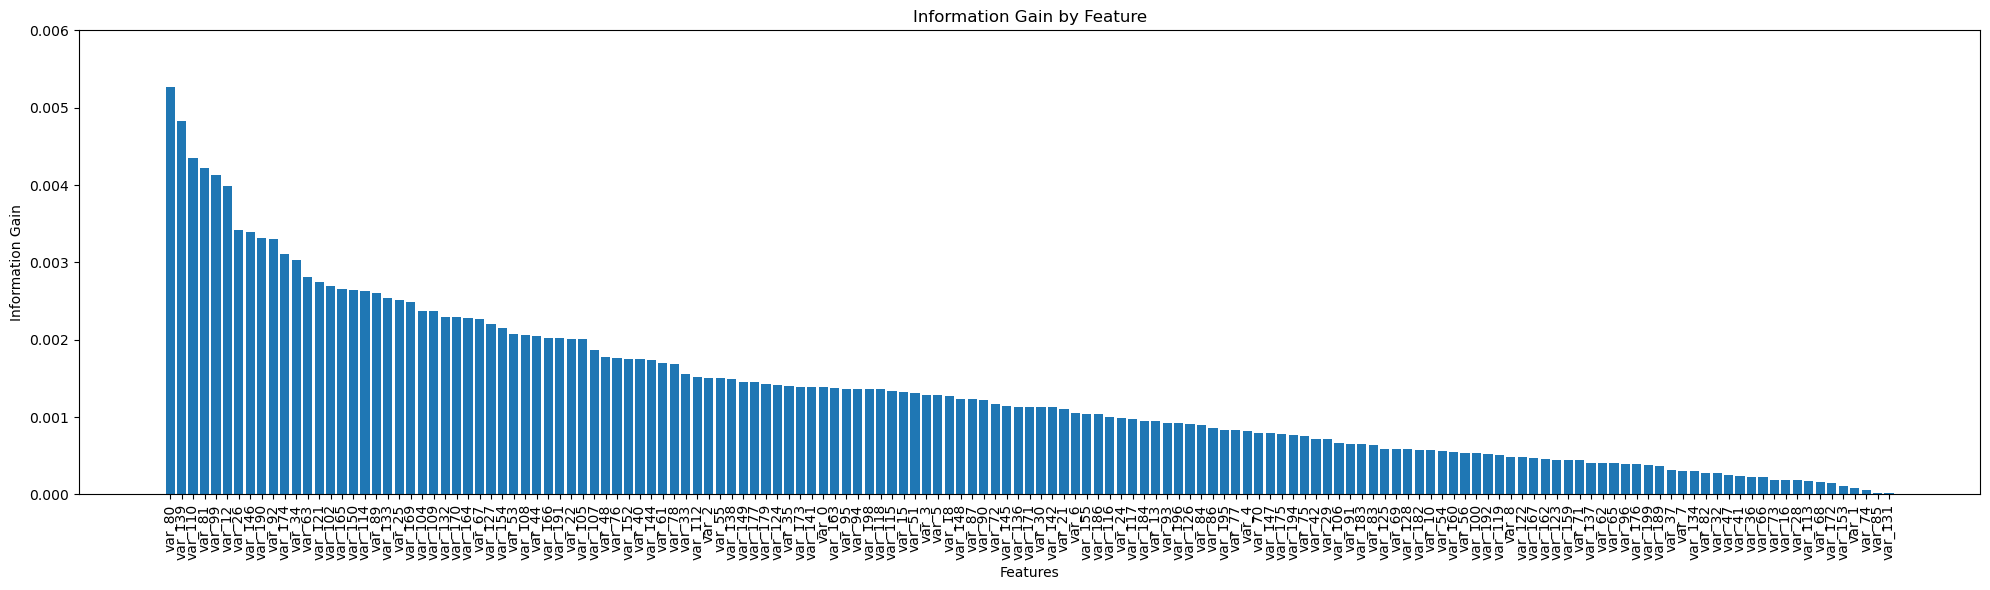

In [17]:
# Create a DataFrame with the results for Information Gain (IG) for Pipeline A
weights_A = pd.DataFrame({
    'attr_importance': ig_scores_A
}, index=X_A_train.columns)

# Print weights
print("Information Gain (Mutual Information) Scores:")
print(weights_A)

# Filter for weights with positive information gain values and sort in decreasing order
weights_sort_A = weights_A[weights_A['attr_importance'] > 0]
weights_sort_A = weights_sort_A.sort_values('attr_importance', ascending=False)

# Filter the features with positive information gain
features_A = weights_sort_A.index.tolist()
print(f"Number of features with positive information gain: {len(features_A)}")
print(f"\nFeatures with positive information gain:")
print(features_A)

# Plot the features
plt.figure(figsize=(20, 6))
plt.bar(range(len(weights_sort_A)), weights_sort_A['attr_importance'])
plt.xticks(range(len(weights_sort_A)), weights_sort_A.index, rotation=90)
plt.ylim(0, 0.006)
plt.xlabel('Features')
plt.ylabel('Information Gain')
plt.title('Information Gain by Feature')
plt.tight_layout()
plt.show()

Information Gain (Mutual Information) Scores:
         attr_importance
var_0           0.001525
var_1           0.000260
var_2           0.001013
var_3           0.001267
var_4           0.001303
...                  ...
var_195         0.000802
var_196         0.000839
var_197         0.000000
var_198         0.001485
var_199         0.000511

[200 rows x 1 columns]
Number of features with positive information gain: 157

Features with positive information gain:
['var_80', 'var_139', 'var_110', 'var_146', 'var_99', 'var_81', 'var_26', 'var_34', 'var_190', 'var_92', 'var_174', 'var_104', 'var_166', 'var_114', 'var_133', 'var_121', 'var_132', 'var_89', 'var_45', 'var_12', 'var_165', 'var_102', 'var_105', 'var_164', 'var_150', 'var_127', 'var_63', 'var_109', 'var_25', 'var_44', 'var_148', 'var_154', 'var_68', 'var_53', 'var_170', 'var_107', 'var_152', 'var_48', 'var_33', 'var_138', 'var_67', 'var_55', 'var_112', 'var_94', 'var_93', 'var_40', 'var_78', 'var_169', 'var_141', 'var_191', 'var

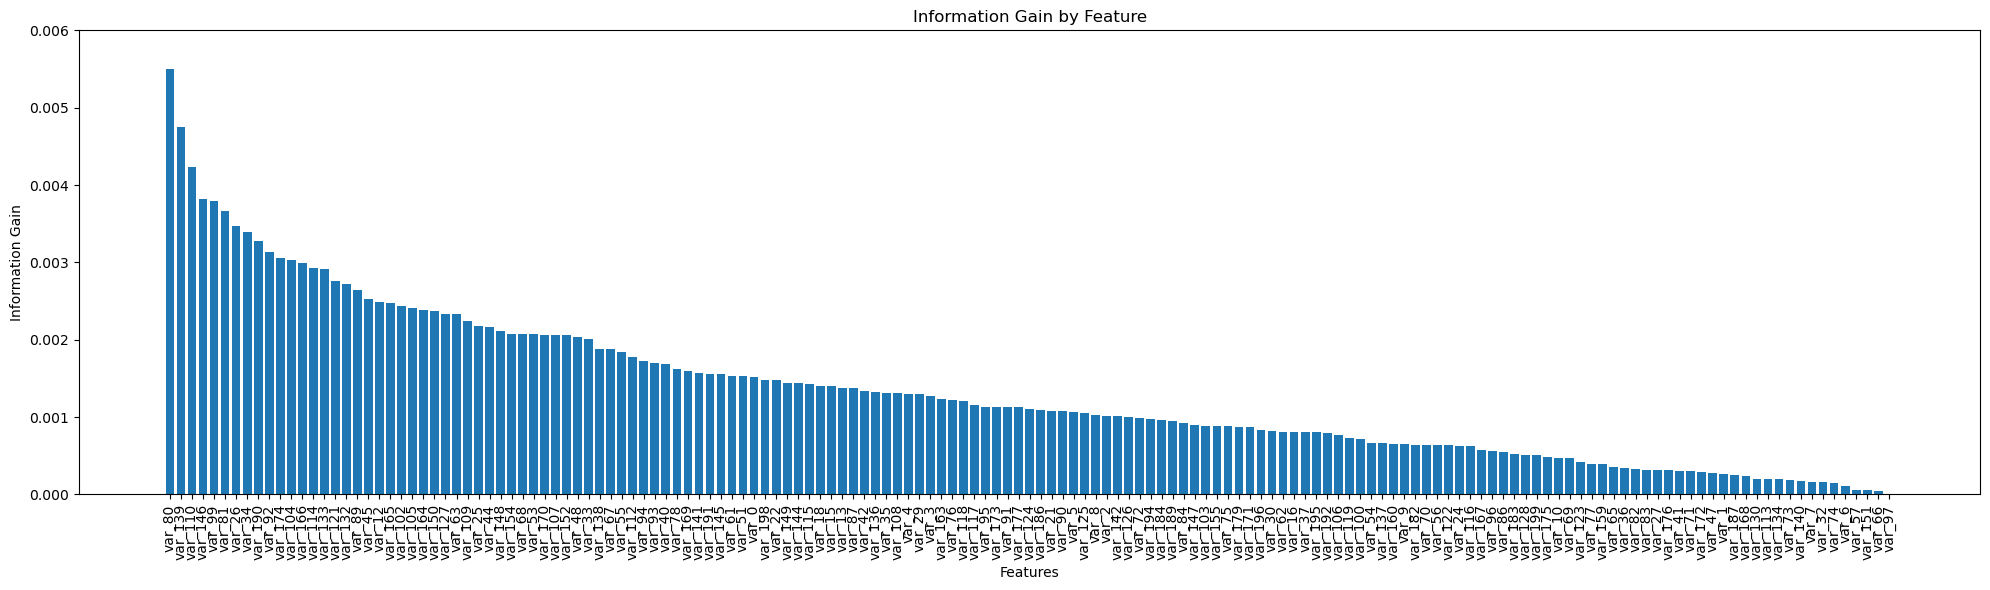

In [18]:
# Create a DataFrame with the results for Information Gain (IG) for Pipeline B
weights_B = pd.DataFrame({
    'attr_importance': ig_scores_B
}, index=X_B_train.columns)

# Print weights
print("Information Gain (Mutual Information) Scores:")
print(weights_B)

# Filter for weights with positive information gain values and sort in decreasing order
weights_sort_B = weights_B[weights_B['attr_importance'] > 0]
weights_sort_B = weights_sort_B.sort_values('attr_importance', ascending=False)

# Filter the features with positive information gain
features_B = weights_sort_B.index.tolist()
print(f"Number of features with positive information gain: {len(features_B)}")
print(f"\nFeatures with positive information gain:")
print(features_B)

# Plot the features
plt.figure(figsize=(20, 6))
plt.bar(range(len(weights_sort_B)), weights_sort_B['attr_importance'])
plt.xticks(range(len(weights_sort_B)), weights_sort_B.index, rotation=90)
plt.ylim(0, 0.006)
plt.xlabel('Features')
plt.ylabel('Information Gain')
plt.title('Information Gain by Feature')
plt.tight_layout()
plt.show()

In [19]:
# Filter train and test data for positive information gain for both pipelines
# Check feature differences
print("\nPipeline A - Information Gain > 0 feature selection:")
print(f"Before: {X_A_train.shape[1]} features")
print(f"After:  {len(features_A)} features selected")

print("\nPipeline B - Information Gain > 0 feature selection:")
print(f"  Before: {X_B_train.shape[1]} features")
print(f"  After:  {len(features_B)} features selected")

# Apply selection to train and test for both pipelines
X_A_train_selected = X_A_train[features_A]
X_A_test_selected  = X_A_test[features_A]
print("\nPipeline A - Final Selected Data Shapes:")
print(f"  Train: {X_A_train_selected.shape}")
print(f"  Test:  {X_A_test_selected.shape}")

X_B_train_selected = X_B_train[features_B]
X_B_test_selected  = X_B_test[features_B]
print("\nPipeline B - Final Selected Data Shapes:")
print(f"  Train: {X_B_train_selected.shape}")
print(f"  Test:  {X_B_test_selected.shape}")


Pipeline A - Information Gain > 0 feature selection:
Before: 199 features
After:  151 features selected

Pipeline B - Information Gain > 0 feature selection:
  Before: 200 features
  After:  157 features selected

Pipeline A - Final Selected Data Shapes:
  Train: (80000, 151)
  Test:  (20000, 151)

Pipeline B - Final Selected Data Shapes:
  Train: (80000, 157)
  Test:  (20000, 157)


In [20]:
# Check feature overlap between pipelines after filtering for positive IG
common_features = set(features_A).intersection(set(features_B))
unique_to_A = set(features_A) - set(features_B)
unique_to_B = set(features_B) - set(features_A)
print(f"\nFeatures selected by both pipelines: {len(common_features)}")
print(f"Features only in Pipeline A: {len(unique_to_A)}")
print(f"Features only in Pipeline B: {len(unique_to_B)}")

if len(unique_to_A) > 0:
    print(f"\nUnique to Pipeline A: {sorted(list(unique_to_A))}")
if len(unique_to_B) > 0:
    print(f"\nUnique to Pipeline B: {sorted(list(unique_to_B))}")

print("\nPipeline A (Drop high-missingness variables + Median imputation):")
print(f"Original features: {len(X_A_train.columns)}")
print(f"Selected features: {len(features_A)}")
print(f"Training sample:   {X_A_train_selected.shape}")
print(f"Test sample:       {X_A_test_selected.shape}")

print("\nPipeline B (Keep all variables + Median imputation):")
print(f"Original features: {len(X_B_train.columns)}")
print(f"Selected features: {len(features_B)}")
print(f"Training sample:   {X_B_train_selected.shape}")
print(f"Test sample:       {X_B_test_selected.shape}")


Features selected by both pipelines: 146
Features only in Pipeline A: 5
Features only in Pipeline B: 11

Unique to Pipeline A: ['var_131', 'var_153', 'var_162', 'var_28', 'var_85']

Unique to Pipeline B: ['var_103', 'var_130', 'var_140', 'var_151', 'var_168', 'var_187', 'var_27', 'var_45', 'var_57', 'var_9', 'var_97']

Pipeline A (Drop high-missingness variables + Median imputation):
Original features: 199
Selected features: 151
Training sample:   (80000, 151)
Test sample:       (20000, 151)

Pipeline B (Keep all variables + Median imputation):
Original features: 200
Selected features: 157
Training sample:   (80000, 157)
Test sample:       (20000, 157)


In [21]:
# Building models using features with positive IG features only


Random Forest Model (Pipeline A) trained successfully.
Random Forest Model - Pipeline A
Number of trees: 100
Number of features used: 151
Training accuracy: 1.0000

Pipeline A - Top 20 Features (Random Forest)
    Feature  Importance
3    var_81    0.017837
1   var_139    0.016031
5    var_12    0.013763
7   var_146    0.012749
30   var_53    0.012427
2   var_110    0.012387
79    var_6    0.011715
35   var_22    0.011617
6    var_26    0.010797
4    var_99    0.010124
10  var_174    0.009901
0    var_80    0.009620
23  var_109    0.009498
8   var_190    0.009365
78   var_21    0.009094
69  var_148    0.009089
33  var_166    0.009084
32   var_44    0.008884
61  var_198    0.008848
47    var_2    0.008770


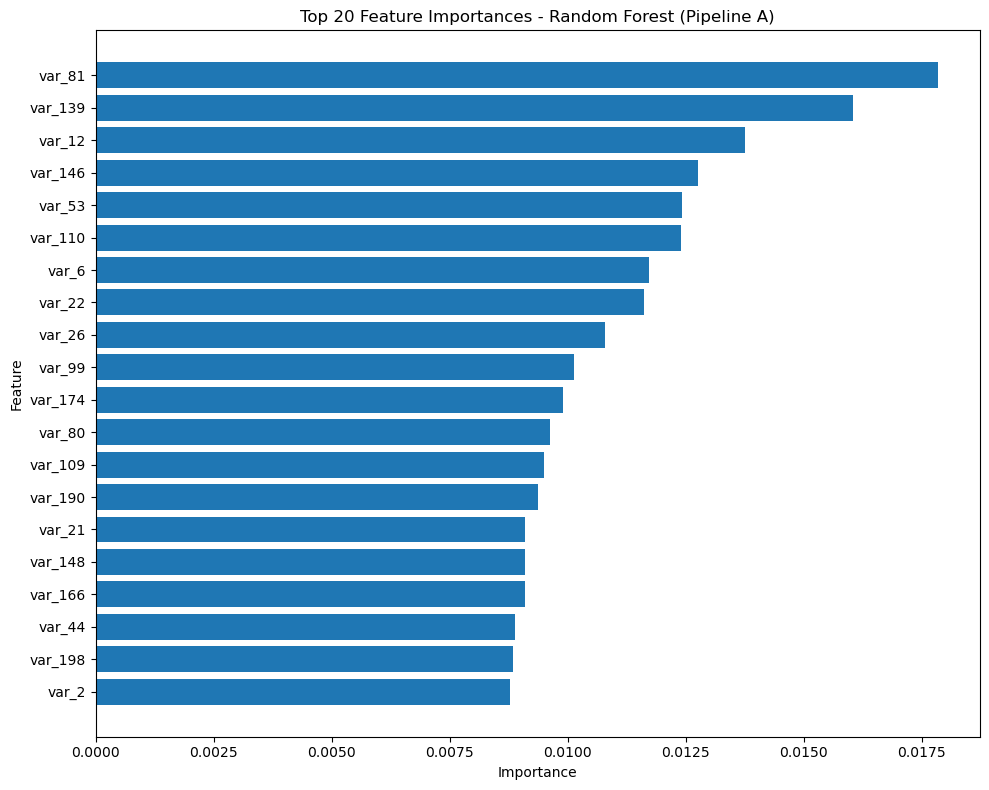

In [22]:
# Random Forest model Pipeline A
model_RF_A = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    class_weight="balanced",
    random_state=random_seed
)

# Fit the model on selected features WITH ORIGINAL labels
model_RF_A.fit(X_A_train_selected, y_A_train)
print("\nRandom Forest Model (Pipeline A) trained successfully.")

# Print model summary
print("Random Forest Model - Pipeline A")
print(f"Number of trees: {model_RF_A.n_estimators}")
print(f"Number of features used: {model_RF_A.n_features_in_}")
print(f"Training accuracy: {model_RF_A.score(X_A_train_selected, y_A_train):.4f}")

# Feature importances (top 20)
feature_importance_rf_A = pd.DataFrame({
    'Feature': features_A,
    'Importance': model_RF_A.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nPipeline A - Top 20 Features (Random Forest)")
print(feature_importance_rf_A.head(20))

# Plot top 20 feature importances
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_rf_A['Feature'].head(20), feature_importance_rf_A['Importance'].head(20))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances - Random Forest (Pipeline A)')
plt.gca().invert_yaxis()   # highest importance at top
plt.tight_layout()
plt.show()


Random Forest Model (Pipeline B) trained successfully.
Random Forest Model - Pipeline B
Number of trees: 100
Number of features used: 157
Training accuracy: 1.0000

Pipeline B - Top 20 Features (Random Forest)
     Feature  Importance
5     var_81    0.017833
1    var_139    0.015833
19    var_12    0.013633
2    var_110    0.012387
3    var_146    0.012170
55    var_22    0.012103
33    var_53    0.011761
152    var_6    0.011622
6     var_26    0.011218
4     var_99    0.009669
0     var_80    0.009588
80    var_21    0.009402
8    var_190    0.009243
30   var_148    0.009179
10   var_174    0.009022
27   var_109    0.009015
29    var_44    0.008883
12   var_166    0.008882
71    var_76    0.008645
85     var_2    0.008590


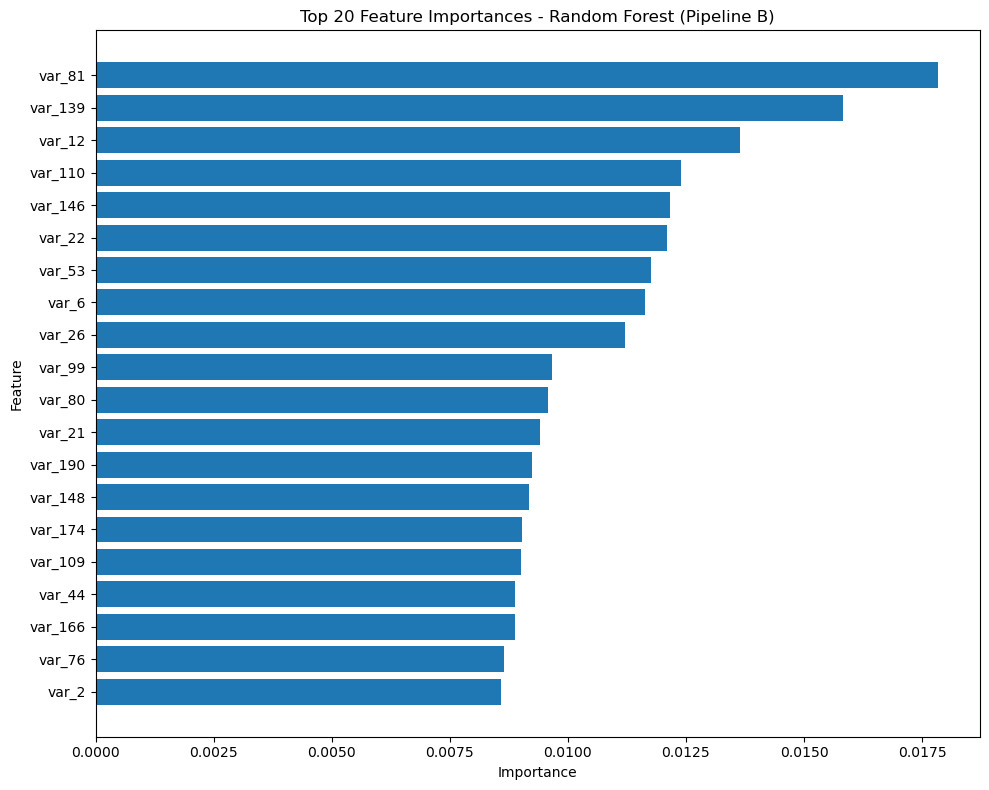

In [23]:
# Random Forest model Pipeline B
model_RF_B = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    class_weight="balanced",
    random_state=random_seed
)

# Fit the model on selected features WITH ORIGINAL labels
model_RF_B.fit(X_B_train_selected, y_B_train)
print("\nRandom Forest Model (Pipeline B) trained successfully.")

# Print model summary
print("Random Forest Model - Pipeline B")
print(f"Number of trees: {model_RF_B.n_estimators}")
print(f"Number of features used: {model_RF_B.n_features_in_}")
print(f"Training accuracy: {model_RF_B.score(X_B_train_selected, y_B_train):.4f}")

# Feature importances (top 20)
feature_importance_rf_B = pd.DataFrame({
    'Feature': features_B,
    'Importance': model_RF_B.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nPipeline B - Top 20 Features (Random Forest)")
print(feature_importance_rf_B.head(20))

# Plot top 20 feature importances
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_rf_B['Feature'].head(20), feature_importance_rf_B['Importance'].head(20))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances - Random Forest (Pipeline B)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
# Random Forest Pipeline A evaluation
# Predict classes
prediction_RF_A = model_RF_A.predict(X_A_test_selected)
print("First 10 predictions (Pipeline A):")
print(prediction_RF_A[:10])

# Confusion matrix
print("\nConfusion Matrix - Random Forest (Pipeline A):")
print(confusion_matrix(y_A_test, prediction_RF_A))

# Classification report
print("\nClassification Report - Random Forest (Pipeline A):")
print(classification_report(y_A_test, prediction_RF_A))

# Calculate specific metrics
accuracy_RF_A = accuracy_score(y_A_test, prediction_RF_A)
precision_RF_A = precision_score(y_A_test, prediction_RF_A)
recall_RF_A = recall_score(y_A_test, prediction_RF_A)
f1_RF_A = f1_score(y_A_test, prediction_RF_A)

print(f"\nMetrics for Random Forest for Pipeline A:")
print(f"Accuracy: {accuracy_RF_A:.4f}")
print(f"Precision: {precision_RF_A:.4f}")
print(f"Recall (Sensitivity): {recall_RF_A:.4f}")
print(f"F1-Score: {f1_RF_A:.4f}")

First 10 predictions (Pipeline A):
[0 0 0 0 0 0 0 0 0 0]

Confusion Matrix - Random Forest (Pipeline A):
[[17992     0]
 [ 2008     0]]

Classification Report - Random Forest (Pipeline A):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     17992
           1       0.00      0.00      0.00      2008

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000


Metrics for Random Forest for Pipeline A:
Accuracy: 0.8996
Precision: 0.0000
Recall (Sensitivity): 0.0000
F1-Score: 0.0000


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\anaconda3\Lib\site-packages\s

In [25]:
# Random Forest Pipeline B evaluation
# Predict classes
prediction_RF_B = model_RF_B.predict(X_B_test_selected)
print("First 10 predictions (Pipeline B):")
print(prediction_RF_B[:10])

# Confusion matrix
print("\nConfusion Matrix - Random Forest (Pipeline B):")
print(confusion_matrix(y_B_test, prediction_RF_B))

# Classification report
print("\nClassification Report - Random Forest (Pipeline B):")
print(classification_report(y_B_test, prediction_RF_B))

# Calculate specific metrics
accuracy_RF_B = accuracy_score(y_B_test, prediction_RF_B)
precision_RF_B = precision_score(y_B_test, prediction_RF_B)
recall_RF_B = recall_score(y_B_test, prediction_RF_B)
f1_RF_B = f1_score(y_B_test, prediction_RF_B)

print(f"\nMetrics for Random Forest for Pipeline B:")
print(f"Accuracy: {accuracy_RF_B:.4f}")
print(f"Precision: {precision_RF_B:.4f}")
print(f"Recall (Sensitivity): {recall_RF_B:.4f}")
print(f"F1-Score: {f1_RF_B:.4f}")

First 10 predictions (Pipeline B):
[0 0 0 0 0 0 0 0 0 0]

Confusion Matrix - Random Forest (Pipeline B):
[[17992     0]
 [ 2008     0]]

Classification Report - Random Forest (Pipeline B):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     17992
           1       0.00      0.00      0.00      2008

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000


Metrics for Random Forest for Pipeline B:
Accuracy: 0.8996
Precision: 0.0000
Recall (Sensitivity): 0.0000
F1-Score: 0.0000


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\anaconda3\Lib\site-packages\s

Random Forest (Pipeline A) AUC: 0.7789
Random Forest (Pipeline B) AUC: 0.7732


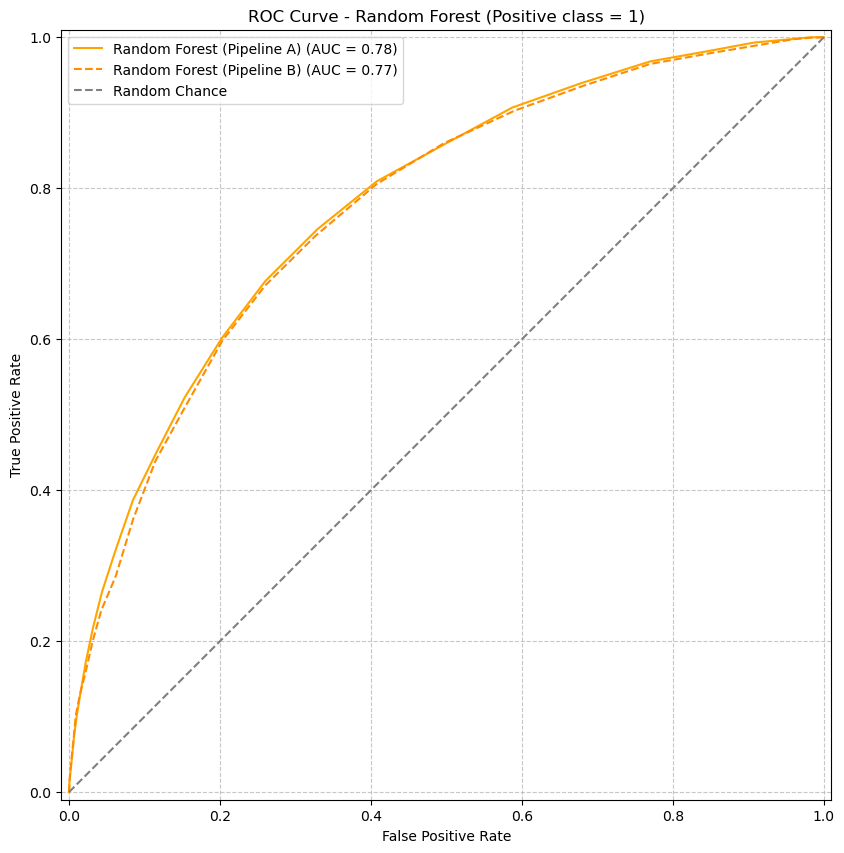

In [26]:
# Random Forest plot ROC curve
fig, ax = plt.subplots(figsize=(10, 10))

prob_RF_A = model_RF_A.predict_proba(X_A_test_selected)[:, 1]
auc_RF_A = roc_auc_score(y_A_test, prob_RF_A)
print(f"Random Forest (Pipeline A) AUC: {auc_RF_A:.4f}")

prob_RF_B = model_RF_B.predict_proba(X_B_test_selected)[:, 1]
auc_RF_B = roc_auc_score(y_B_test, prob_RF_B)
print(f"Random Forest (Pipeline B) AUC: {auc_RF_B:.4f}")

RocCurveDisplay.from_predictions(y_A_test, prob_RF_A, name="Random Forest (Pipeline A)", color="orange",ax=ax)
RocCurveDisplay.from_predictions(y_B_test, prob_RF_B, name="Random Forest (Pipeline B)", color="darkorange", linestyle="--", ax=ax)
ax.plot([0, 1], [0, 1], "--", label="Random Chance", color="grey") # Unmodelled random chance as baseline for comparison
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Random Forest (Positive class = 1)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.7)


Logistic Regression Model (Pipeline A) trained successfully.
Logistic Regression - Pipeline A
Number of iterations: [2487]
Number of features used: 151
Training accuracy: 0.7680

Pipeline A - Top 20 Features (Permutation Importance)
    Feature  Importance
3    var_81    0.009090
1   var_139    0.006389
5    var_12    0.006364
30   var_53    0.005991
35   var_22    0.005827
79    var_6    0.005273
6    var_26    0.004915
7   var_146    0.004810
39   var_76    0.004802
4    var_99    0.004758
86   var_13    0.004323
78   var_21    0.004205
57    var_0    0.004149
10  var_174    0.003854
34  var_191    0.003736
8   var_190    0.003663
45   var_33    0.003577
33  var_166    0.003373
47    var_2    0.003373
15  var_165    0.003354


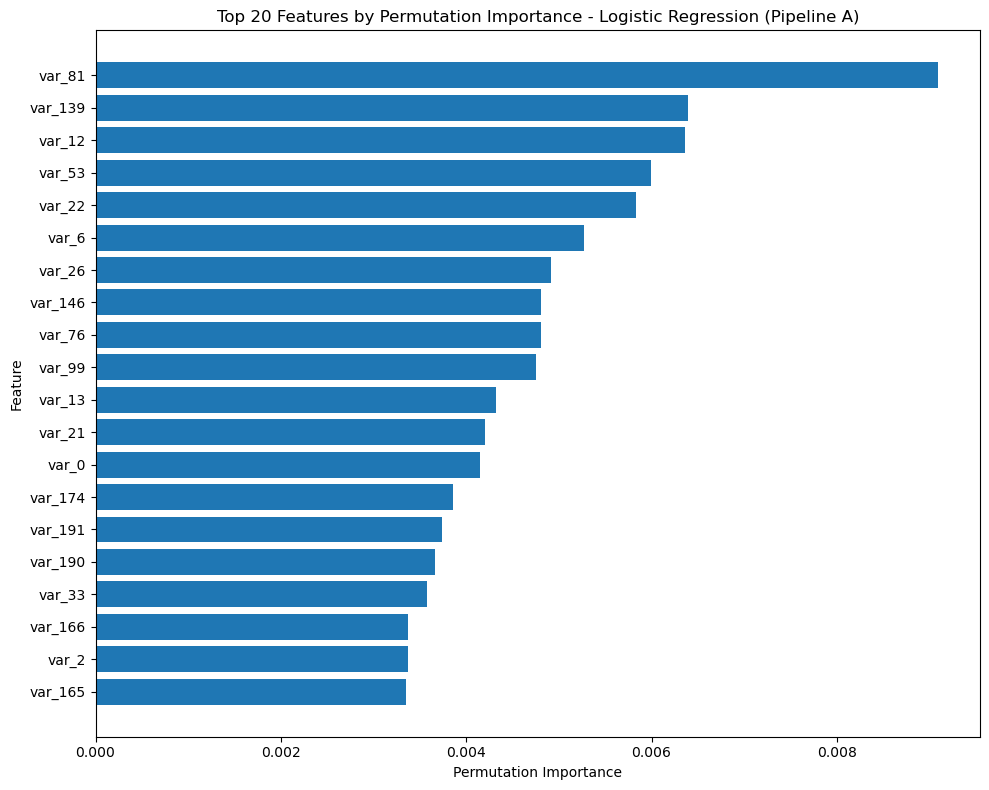

In [27]:
# Logistic Regression model Pipeline A
model_LR_A = LogisticRegression(max_iter=10000, class_weight = "balanced", random_state=random_seed)

# Fit the model on selected features WITH ORIGINAL labels
model_LR_A.fit(X_A_train_selected, y_A_train)
print("\nLogistic Regression Model (Pipeline A) trained successfully.")

# Print model summary
print("Logistic Regression - Pipeline A")
print(f"Number of iterations: {model_LR_A.n_iter_}")
print(f"Number of features used: {model_LR_A.n_features_in_}")
print(f"Training accuracy: {model_LR_A.score(X_A_train_selected, y_A_train):.4f}")

# Feature Importance using permutation (top 20)
result_LR_A = permutation_importance(
    model_LR_A,
    X_A_test_selected,
    y_A_test,
    n_repeats=30,
    random_state=random_seed,
    scoring='roc_auc')

perm_importance_A = pd.DataFrame({
    'Feature': features_A,
    'Importance': result_LR_A.importances_mean
}).sort_values('Importance', ascending=False)

print("\nPipeline A - Top 20 Features (Permutation Importance)")
print(perm_importance_A.head(20))

# Plot top 20 permutation importance
plt.figure(figsize=(10, 8))
plt.barh(perm_importance_A['Feature'].head(20), perm_importance_A['Importance'].head(20))
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.title('Top 20 Features by Permutation Importance - Logistic Regression (Pipeline A)')
plt.gca().invert_yaxis()  # Put highest at the top
plt.tight_layout()
plt.show()


Logistic Regression Model (Pipeline B) trained successfully.
Logistic Regression - Pipeline B
Number of iterations: [2265]
Number of features used: 157
Training accuracy: 0.7689

Pipeline B - Top 20 Features (Permutation Importance)
     Feature  Importance
5     var_81    0.008852
1    var_139    0.006718
19    var_12    0.006428
33    var_53    0.006088
55    var_22    0.005994
152    var_6    0.005571
3    var_146    0.004959
71    var_76    0.004878
4     var_99    0.004810
6     var_26    0.004803
61    var_13    0.004490
53     var_0    0.004274
80    var_21    0.004158
10   var_174    0.003899
8    var_190    0.003712
49   var_191    0.003529
45    var_40    0.003494
38    var_33    0.003480
30   var_148    0.003452
20   var_165    0.003356


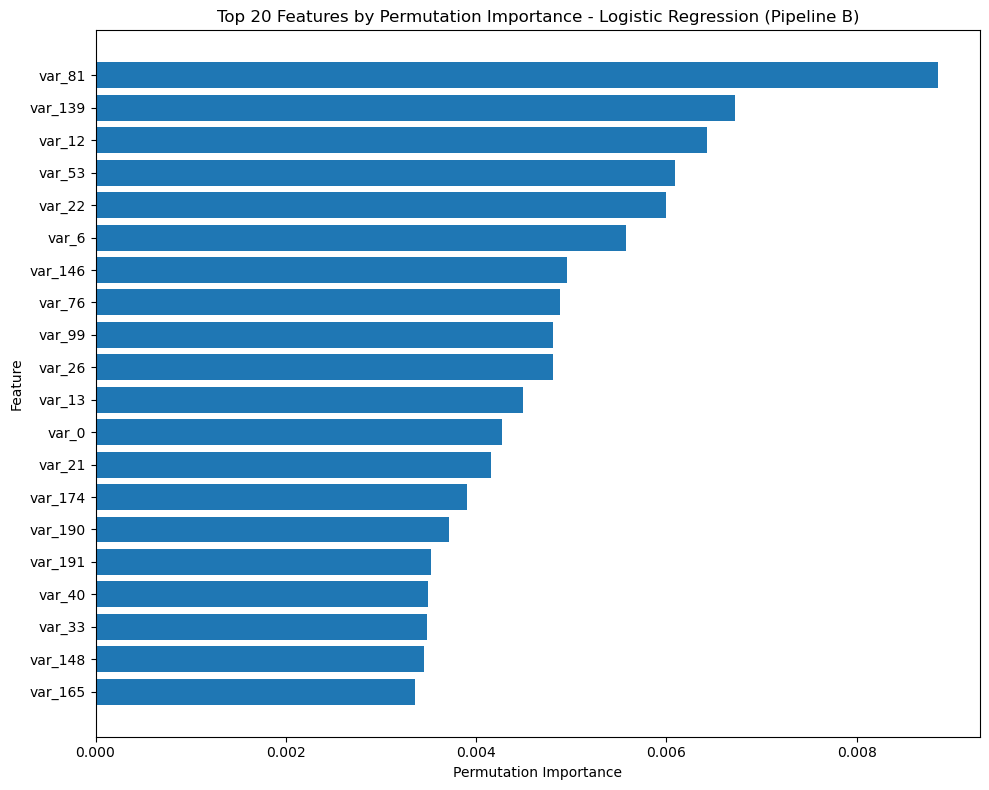

In [28]:
# Logistic Regression model Pipeline B
model_LR_B = LogisticRegression(max_iter=10000, class_weight = "balanced", random_state=random_seed)

# Fit the model on selected features WITH ORIGINAL labels
model_LR_B.fit(X_B_train_selected, y_B_train)
print("\nLogistic Regression Model (Pipeline B) trained successfully.")

# Print model summary
print("Logistic Regression - Pipeline B")
print(f"Number of iterations: {model_LR_B.n_iter_}")
print(f"Number of features used: {model_LR_B.n_features_in_}")
print(f"Training accuracy: {model_LR_B.score(X_B_train_selected, y_B_train):.4f}")

# Feature Importance using permutation (top 20)
result_LR_B = permutation_importance(
    model_LR_B,
    X_B_test_selected,
    y_B_test,
    n_repeats=30,
    random_state=random_seed,
    scoring='roc_auc')

perm_importance_B = pd.DataFrame({
    'Feature': features_B,
    'Importance': result_LR_B.importances_mean
}).sort_values('Importance', ascending=False)

print("\nPipeline B - Top 20 Features (Permutation Importance)")
print(perm_importance_B.head(20))

# Plot top 20 permutation importance
plt.figure(figsize=(10, 8))
plt.barh(perm_importance_B['Feature'].head(20), perm_importance_B['Importance'].head(20))
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.title('Top 20 Features by Permutation Importance - Logistic Regression (Pipeline B)')
plt.gca().invert_yaxis()  # Put highest at the top
plt.tight_layout()
plt.show()

First 10 predictions (Pipeline A):
[0 0 0 1 0 0 1 1 0 1]

Confusion Matrix - Logistic Regression (Pipeline A):
[[13846  4146]
 [  459  1549]]

Classification Report - Logistic Regression (Pipeline A):
              precision    recall  f1-score   support

           0       0.97      0.77      0.86     17992
           1       0.27      0.77      0.40      2008

    accuracy                           0.77     20000
   macro avg       0.62      0.77      0.63     20000
weighted avg       0.90      0.77      0.81     20000


Metrics for Logistic Regression for Pipeline A:
Accuracy: 0.7698
Precision: 0.2720
Recall (Sensitivity): 0.7714
F1-Score: 0.4022


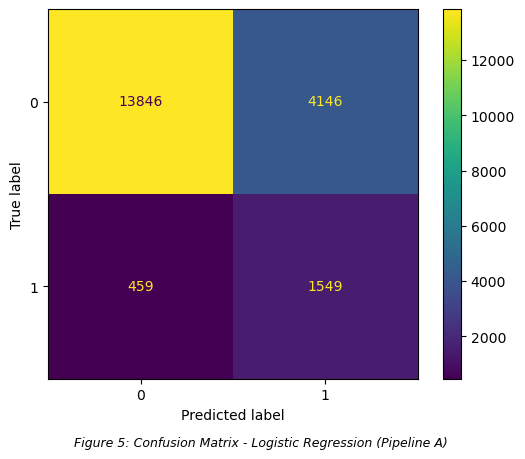

In [185]:
# Logistic Regression Pipeline A evaluation
# Predict classes
prediction_LR_A = model_LR_A.predict(X_A_test_selected)
print("First 10 predictions (Pipeline A):")
print(prediction_LR_A[:10])

# Confusion matrix
print("\nConfusion Matrix - Logistic Regression (Pipeline A):")
print(confusion_matrix(y_A_test, prediction_LR_A))

# Classification report
print("\nClassification Report - Logistic Regression (Pipeline A):")
print(classification_report(y_A_test, prediction_LR_A))

# Calculate specific metrics
accuracy_LR_A = accuracy_score(y_A_test, prediction_LR_A)
precision_LR_A = precision_score(y_A_test, prediction_LR_A)
recall_LR_A = recall_score(y_A_test, prediction_LR_A)
f1_LR_A = f1_score(y_A_test, prediction_LR_A)

print(f"\nMetrics for Logistic Regression for Pipeline A:")
print(f"Accuracy: {accuracy_LR_A:.4f}")
print(f"Precision: {precision_LR_A:.4f}")
print(f"Recall (Sensitivity): {recall_LR_A:.4f}")
print(f"F1-Score: {f1_LR_A:.4f}")

cm_display_LR_A = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_A_test, prediction_LR_A), display_labels = [0, 1])

cm_display_LR_A.plot()
txt = 'Figure 5: Confusion Matrix - Logistic Regression (Pipeline A)'
plt.figtext(0.5, -0.03, txt, ha='center', fontsize=9, fontstyle='italic')
plt.show()

First 10 predictions (Pipeline B):
[0 0 0 1 0 0 1 1 0 1]

Confusion Matrix - Logistic Regression (Pipeline B):
[[13826  4166]
 [  461  1547]]

Classification Report - Logistic Regression (Pipeline B):
              precision    recall  f1-score   support

           0       0.97      0.77      0.86     17992
           1       0.27      0.77      0.40      2008

    accuracy                           0.77     20000
   macro avg       0.62      0.77      0.63     20000
weighted avg       0.90      0.77      0.81     20000


Metrics for Logistic Regression for Pipeline B:
Accuracy: 0.7687
Precision: 0.2708
Recall (Sensitivity): 0.7704
F1-Score: 0.4007


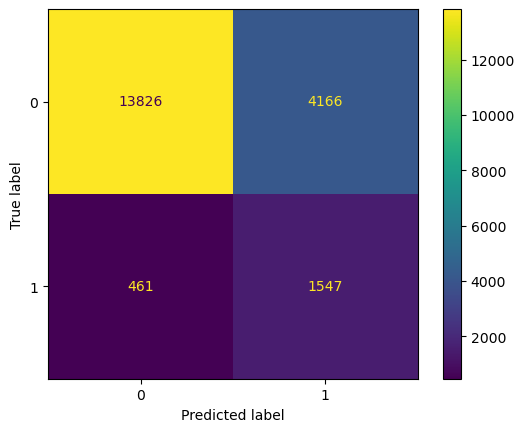

In [181]:
# Logistic Regression Pipeline B evaluation
# Predict classes
prediction_LR_B = model_LR_B.predict(X_B_test_selected)
print("First 10 predictions (Pipeline B):")
print(prediction_LR_B[:10])

# Confusion matrix
print("\nConfusion Matrix - Logistic Regression (Pipeline B):")
print(confusion_matrix(y_B_test, prediction_LR_B))

# Classification report
print("\nClassification Report - Logistic Regression (Pipeline B):")
print(classification_report(y_B_test, prediction_LR_B))

# Calculate specific metrics
accuracy_LR_B = accuracy_score(y_B_test, prediction_LR_B)
precision_LR_B = precision_score(y_B_test, prediction_LR_B)
recall_LR_B = recall_score(y_B_test, prediction_LR_B)
f1_LR_B = f1_score(y_B_test, prediction_LR_B)

print(f"\nMetrics for Logistic Regression for Pipeline B:")
print(f"Accuracy: {accuracy_LR_B:.4f}")
print(f"Precision: {precision_LR_B:.4f}")
print(f"Recall (Sensitivity): {recall_LR_B:.4f}")
print(f"F1-Score: {f1_LR_B:.4f}")

cm_display_LR_B = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_B_test, prediction_LR_B), display_labels = [0, 1])

cm_display_LR_B.plot()
plt.show()

Random Forest (Pipeline A) AUC: 0.8536
Random Forest (Pipeline B) AUC: 0.8546


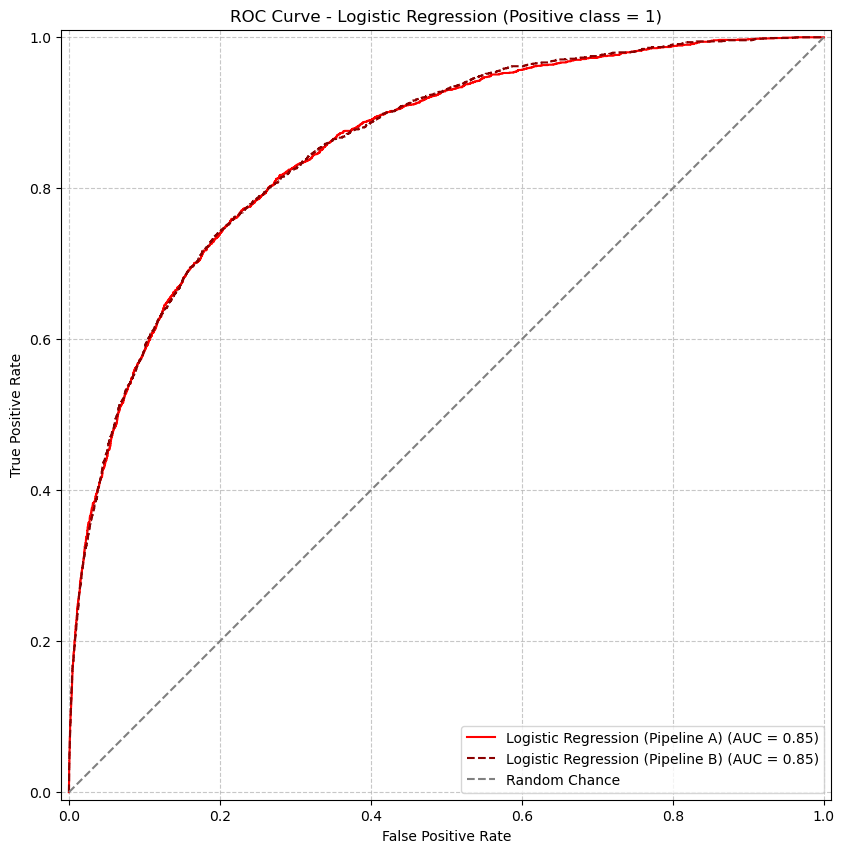

In [31]:
# Logistic Regression plot ROC curve
fig, ax = plt.subplots(figsize=(10, 10))

prob_LR_A = model_LR_A.predict_proba(X_A_test_selected)[:, 1]
auc_LR_A = roc_auc_score(y_A_test, prob_LR_A)
print(f"Random Forest (Pipeline A) AUC: {auc_LR_A:.4f}")

prob_LR_B = model_LR_B.predict_proba(X_B_test_selected)[:, 1]
auc_LR_B = roc_auc_score(y_B_test, prob_LR_B)
print(f"Random Forest (Pipeline B) AUC: {auc_LR_B:.4f}")

RocCurveDisplay.from_predictions(y_A_test, prob_LR_A, name="Logistic Regression (Pipeline A)", color="red",ax=ax)
RocCurveDisplay.from_predictions(y_B_test, prob_LR_B, name="Logistic Regression (Pipeline B)", color="darkred", linestyle="--", ax=ax)
ax.plot([0, 1], [0, 1], "--", label="Random Chance", color="grey") # Unmodelled random chance as baseline for comparison
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Logistic Regression (Positive class = 1)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.7)

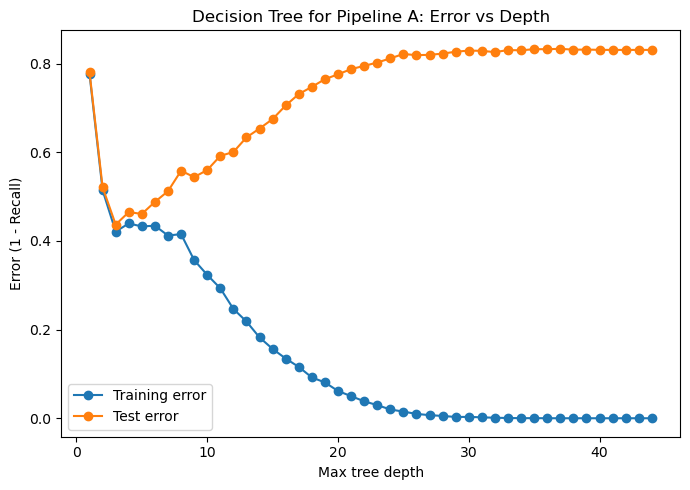

Best depth for Pipeline A: 3
Best CV score Pipeline A: 0.5631382316313822


In [98]:
# Decision Tree - finding best depth for Pipeline A (targetting recall rate)
# Define search space for max_depth
param_grid_A = {
    'max_depth': range(1, 45)
}

# create grid search object for cross-validation
grid_A = GridSearchCV(
    DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=random_seed),
    param_grid = param_grid_A,
    scoring = 'recall',
    cv = 5,
    return_train_score=True
)

# run the tuning
grid_A.fit(X_A_train_selected, y_A_train)

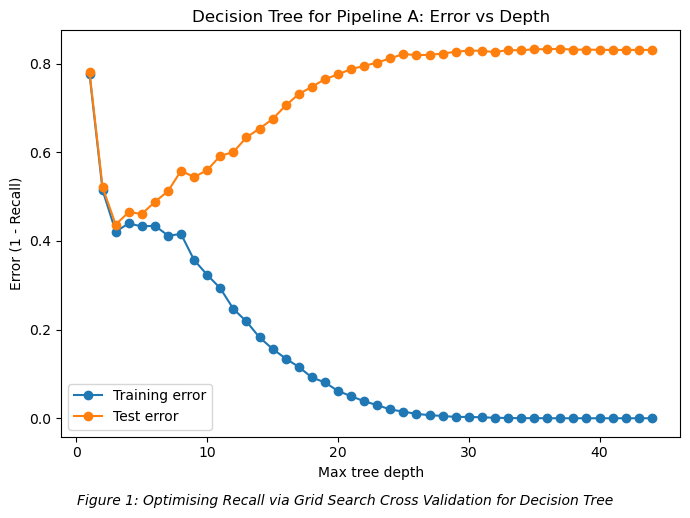

Best depth for Pipeline A: 3
Best CV score Pipeline A: 0.5631382316313822


In [165]:
# take all max_depth values that were tested and turns them into a NumPy array
depths_A = np.array([int(d) for d in grid_A.cv_results_['param_max_depth']])

# sort the depths
order_A = np.argsort(depths_A)

# rearrange depths in sorted order
depths_A = depths_A[order_A]

train_err_A = 1 - grid_A.cv_results_['mean_train_score'][order_A]
val_err_A   = 1 - grid_A.cv_results_['mean_test_score'][order_A]

# plot
txt="Figure 1: Optimising Recall via Grid Search Cross Validation for Decision Tree"

plt.figure(figsize=(7,5))
plt.plot(depths_A, train_err_A, marker='o', label='Training error')
plt.plot(depths_A, val_err_A, marker='o', label='Test error')
plt.xlabel('Max tree depth')
plt.ylabel('Error (1 - Recall)')
plt.title('Decision Tree for Pipeline A: Error vs Depth')
plt.figtext(0.5, -0.02, txt, ha='center', fontsize=10, fontstyle='italic')
plt.legend()
plt.tight_layout()
plt.show()

print("Best depth for Pipeline A:", grid_A.best_params_['max_depth'])
print("Best CV score Pipeline A:", grid_A.best_score_)


Decision Tree Model (Pipeline A) trained successfully.
Decision Tree Model - Pipeline A
Number of trees: 3
Number of leaves: 8
Training accuracy: 0.5703

Pipeline A - Top 20 Features (Decision Tree)
     Feature  Importance
3     var_81    0.369981
1    var_139    0.321845
5     var_12    0.242001
35    var_22    0.046404
30    var_53    0.019769
0     var_80    0.000000
105   var_83    0.000000
99    var_75    0.000000
100   var_42    0.000000
101   var_29    0.000000
102  var_106    0.000000
103   var_91    0.000000
104  var_183    0.000000
107   var_69    0.000000
106  var_125    0.000000
97   var_175    0.000000
108  var_128    0.000000
109  var_182    0.000000
110   var_10    0.000000
111   var_54    0.000000


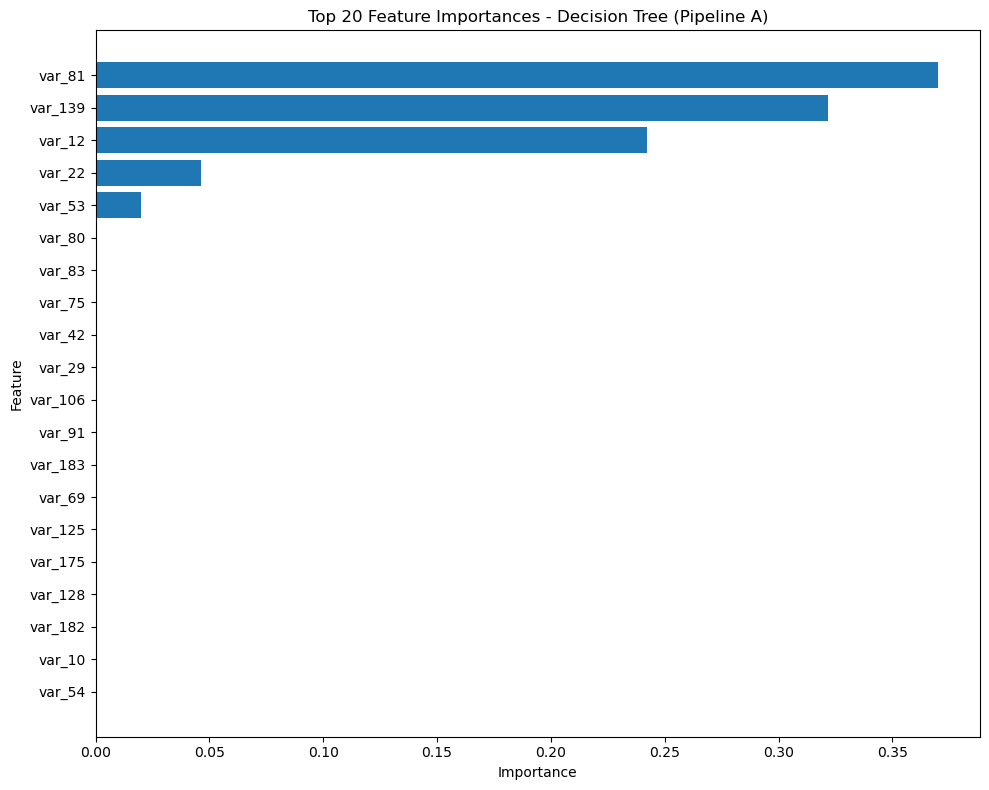

In [80]:
# Decision Tree model Pipeline A (max depth = 3)
model_DT_A = DecisionTreeClassifier(criterion='entropy', max_depth = 3, class_weight='balanced', random_state=random_seed)

# Fit the model on selected features WITH ORIGINAL labels
model_DT_A.fit(X_A_train_selected, y_A_train)
print("\nDecision Tree Model (Pipeline A) trained successfully.")

# Print model summary
print("Decision Tree Model - Pipeline A")
print(f"Number of trees: {model_DT_A.get_depth()}")
print(f"Number of leaves: {model_DT_A.get_n_leaves()}")
print(f"Training accuracy: {model_DT_A.score(X_A_train_selected, y_A_train):.4f}")

# Feature importances (top 20)
feature_importance_dt_A = pd.DataFrame({
    'Feature': features_A,
    'Importance': model_DT_A.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nPipeline A - Top 20 Features (Decision Tree)")
print(feature_importance_dt_A.head(20))

# Plot top 20 feature importances
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_dt_A['Feature'].head(20), feature_importance_dt_A['Importance'].head(20))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances - Decision Tree (Pipeline A)')
plt.gca().invert_yaxis()   # highest importance at top
plt.tight_layout()
plt.show()

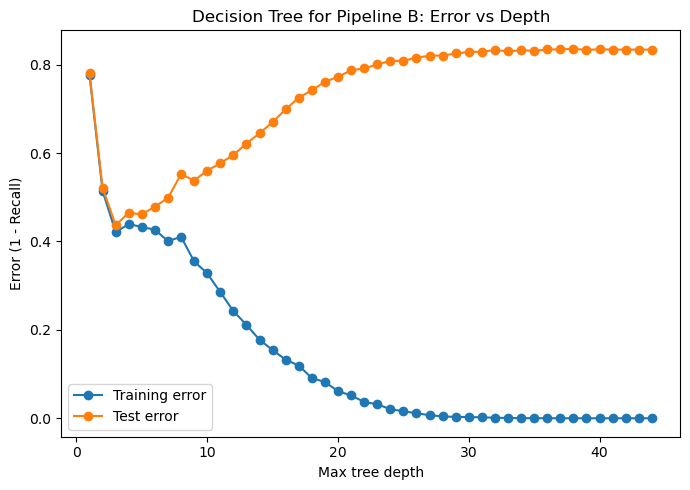

Best depth for Pipeline B: 3
Best CV score Pipeline B: 0.5631382316313822


In [83]:
# Decision Tree - finding best depth for Pipeline B (targetting recall rate)
# Define search space for max_depth
param_grid_B = {
    'max_depth': range(1, 45)
}

# create grid search object for cross-validation
grid_B = GridSearchCV(
    DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=random_seed),
    param_grid = param_grid_B,
    scoring = 'recall',
    cv = 5,
    return_train_score=True
)

# run the tuning
grid_B.fit(X_B_train_selected, y_B_train)

# take all max_depth values that were tested and turns them into a NumPy array
depths_B = np.array([int(d) for d in grid_B.cv_results_['param_max_depth']])

# sort the depths
order_B = np.argsort(depths_B)

# rearrange depths in sorted order
depths_B = depths_B[order_B]

train_err_B = 1 - grid_B.cv_results_['mean_train_score'][order_B]
val_err_B   = 1 - grid_B.cv_results_['mean_test_score'][order_B]

# plot
plt.figure(figsize=(7,5))
plt.plot(depths_B, train_err_B, marker='o', label='Training error')
plt.plot(depths_B, val_err_B, marker='o', label='Test error')
plt.xlabel('Max tree depth')
plt.ylabel('Error (1 - Recall)')
plt.title('Decision Tree for Pipeline B: Error vs Depth')
plt.legend()
plt.tight_layout()
plt.show()

print("Best depth for Pipeline B:", grid_B.best_params_['max_depth'])
print("Best CV score Pipeline B:", grid_B.best_score_)


Decision Tree Model (Pipeline B) trained successfully.
Decision Tree Model - Pipeline B
Number of trees: 3
Number of leaves: 8
Training accuracy: 0.5703

Pipeline B - Top 20 Features (Decision Tree)
     Feature  Importance
5     var_81    0.369981
1    var_139    0.321845
19    var_12    0.242001
55    var_22    0.046404
33    var_53    0.019769
109   var_54    0.000000
103   var_37    0.000000
104  var_195    0.000000
105  var_192    0.000000
106  var_106    0.000000
107  var_119    0.000000
108  var_100    0.000000
0     var_80    0.000000
101   var_62    0.000000
110  var_137    0.000000
111  var_160    0.000000
112    var_9    0.000000
113  var_182    0.000000
114   var_70    0.000000
115   var_56    0.000000


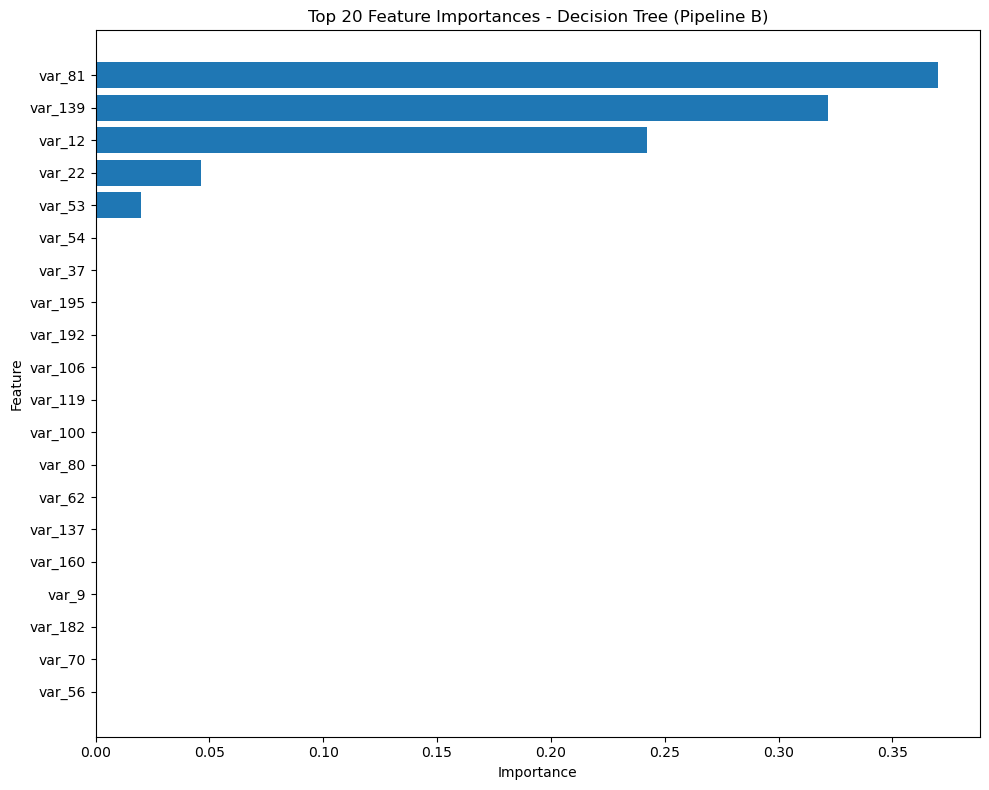

In [91]:
# Decision Tree model Pipeline B (max depth = 3)
model_DT_B = DecisionTreeClassifier(criterion='entropy', max_depth = 3, class_weight='balanced', random_state=random_seed)

# Fit the model on selected features WITH ORIGINAL labels
model_DT_B.fit(X_B_train_selected, y_B_train)
print("\nDecision Tree Model (Pipeline B) trained successfully.")

# Print model summary
print("Decision Tree Model - Pipeline B")
print(f"Number of trees: {model_DT_B.get_depth()}")
print(f"Number of leaves: {model_DT_B.get_n_leaves()}")
print(f"Training accuracy: {model_DT_B.score(X_B_train_selected, y_B_train):.4f}")

# Feature importances (top 20)
feature_importance_dt_B = pd.DataFrame({
    'Feature': features_B,
    'Importance': model_DT_B.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nPipeline B - Top 20 Features (Decision Tree)")
print(feature_importance_dt_B.head(20))

# Plot top 20 feature importances
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_dt_B['Feature'].head(20), feature_importance_dt_B['Importance'].head(20))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances - Decision Tree (Pipeline B)')
plt.gca().invert_yaxis()   # highest importance at top
plt.tight_layout()
plt.show()

First 10 predictions (Pipeline A):
[0 0 1 1 0 1 1 0 0 1]

Confusion Matrix - Decision Tree (Pipeline A):
[[10215  7777]
 [  739  1269]]

Classification Report - Decision Tree (Pipeline A):
              precision    recall  f1-score   support

           0       0.93      0.57      0.71     17992
           1       0.14      0.63      0.23      2008

    accuracy                           0.57     20000
   macro avg       0.54      0.60      0.47     20000
weighted avg       0.85      0.57      0.66     20000


Metrics for Decision Tree for Pipeline A:
Accuracy: 0.5742
Precision: 0.1403
Recall (Sensitivity): 0.6320
F1-Score: 0.2296


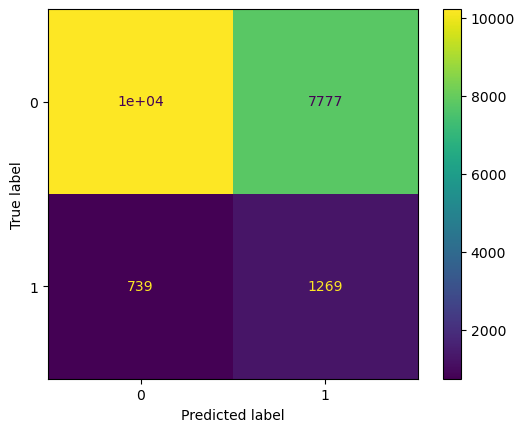

In [81]:
# Decision Tree Pipeline A evaluation
# Predict classes
prediction_DT_A = model_DT_A.predict(X_A_test_selected)
print("First 10 predictions (Pipeline A):")
print(prediction_DT_A[:10])

# Confusion matrix
print("\nConfusion Matrix - Decision Tree (Pipeline A):")
print(confusion_matrix(y_A_test, prediction_DT_A))

# Classification report
print("\nClassification Report - Decision Tree (Pipeline A):")
print(classification_report(y_A_test, prediction_DT_A))

# Calculate specific metrics
accuracy_DT_A = accuracy_score(y_A_test, prediction_DT_A)
precision_DT_A = precision_score(y_A_test, prediction_DT_A)
recall_DT_A = recall_score(y_A_test, prediction_DT_A)
f1_DT_A = f1_score(y_A_test, prediction_DT_A)

print(f"\nMetrics for Decision Tree for Pipeline A:")
print(f"Accuracy: {accuracy_DT_A:.4f}")
print(f"Precision: {precision_DT_A:.4f}")
print(f"Recall (Sensitivity): {recall_DT_A:.4f}")
print(f"F1-Score: {f1_DT_A:.4f}")

cm_display_DT_A = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_A_test, prediction_DT_A), display_labels = [0, 1])

cm_display_DT_A.plot()
plt.show()

First 10 predictions (Pipeline B):
[0 0 1 1 0 1 1 0 0 1]

Confusion Matrix - Decision Tree (Pipeline B):
[[10215  7777]
 [  739  1269]]

Classification Report - Decision Tree (Pipeline B):
              precision    recall  f1-score   support

           0       0.93      0.57      0.71     17992
           1       0.14      0.63      0.23      2008

    accuracy                           0.57     20000
   macro avg       0.54      0.60      0.47     20000
weighted avg       0.85      0.57      0.66     20000


Metrics for Decision Tree for Pipeline B:
Accuracy: 0.5742
Precision: 0.1403
Recall (Sensitivity): 0.6320
F1-Score: 0.2296


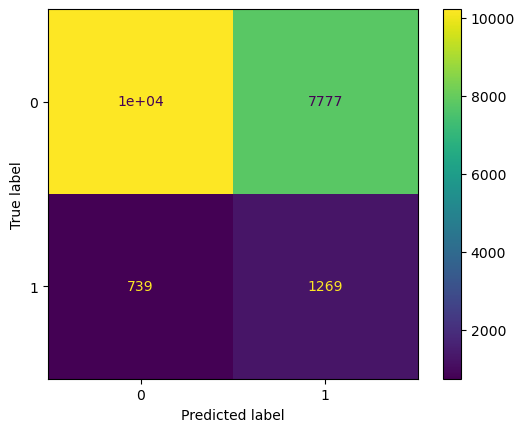

In [92]:
# Decision Tree Pipeline B evaluation
# Predict classes
prediction_DT_B = model_DT_B.predict(X_B_test_selected)
print("First 10 predictions (Pipeline B):")
print(prediction_DT_B[:10])

# Confusion matrix
print("\nConfusion Matrix - Decision Tree (Pipeline B):")
print(confusion_matrix(y_B_test, prediction_DT_B))

# Classification report
print("\nClassification Report - Decision Tree (Pipeline B):")
print(classification_report(y_B_test, prediction_DT_B))

# Calculate specific metrics
accuracy_DT_B = accuracy_score(y_B_test, prediction_DT_B)
precision_DT_B = precision_score(y_B_test, prediction_DT_B)
recall_DT_B = recall_score(y_B_test, prediction_DT_B)
f1_DT_B = f1_score(y_B_test, prediction_DT_B)

print(f"\nMetrics for Decision Tree for Pipeline B:")
print(f"Accuracy: {accuracy_DT_B:.4f}")
print(f"Precision: {precision_DT_B:.4f}")
print(f"Recall (Sensitivity): {recall_DT_B:.4f}")
print(f"F1-Score: {f1_DT_B:.4f}")

cm_display_DT_B = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_B_test, prediction_DT_B), display_labels = [0, 1])

cm_display_DT_B.plot()
plt.show()

Decision Tree (Pipeline A) AUC: 0.6201
Decision Tree (Pipeline B) AUC: 0.6201


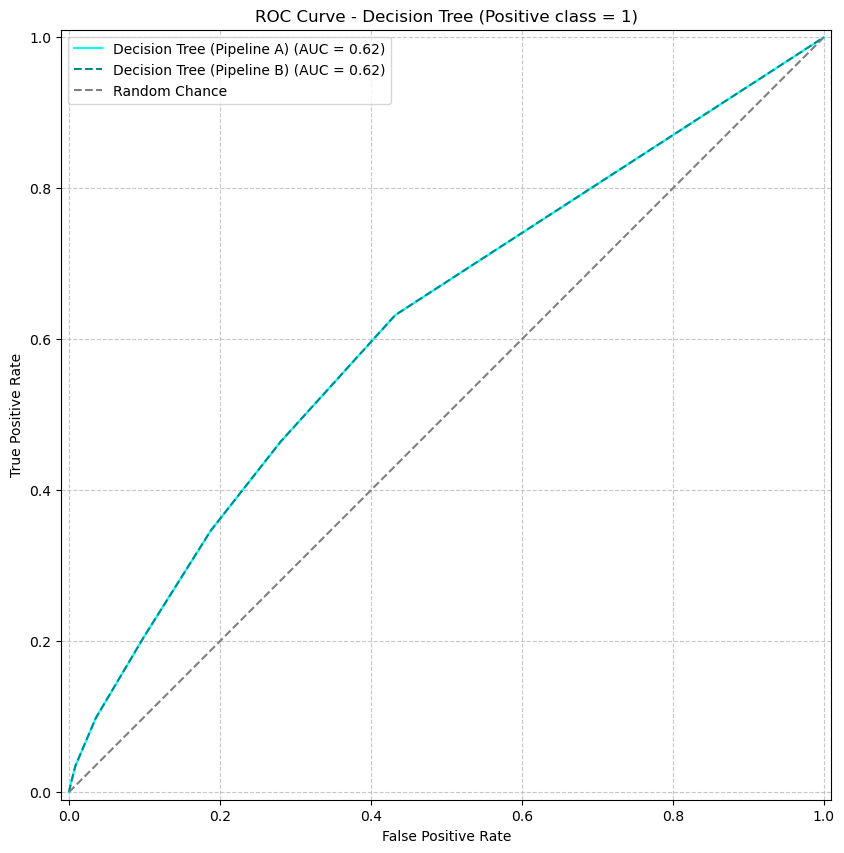

In [93]:
# Decision Tree plot ROC curve
fig, ax = plt.subplots(figsize=(10, 10))

prob_DT_A = model_DT_A.predict_proba(X_A_test_selected)[:, 1]
auc_DT_A = roc_auc_score(y_A_test, prob_DT_A)
print(f"Decision Tree (Pipeline A) AUC: {auc_DT_A:.4f}")

prob_DT_B = model_DT_B.predict_proba(X_B_test_selected)[:, 1]
auc_DT_B = roc_auc_score(y_B_test, prob_DT_B)
print(f"Decision Tree (Pipeline B) AUC: {auc_DT_B:.4f}")

RocCurveDisplay.from_predictions(y_A_test, prob_DT_A, name="Decision Tree (Pipeline A)", color="cyan",ax=ax)
RocCurveDisplay.from_predictions(y_B_test, prob_DT_B, name="Decision Tree (Pipeline B)", color="darkcyan", linestyle="--", ax=ax)
ax.plot([0, 1], [0, 1], "--", label="Random Chance", color="grey") # Unmodelled random chance as baseline for comparison
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Decision Tree (Positive class = 1)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.7)

XGBoost version: 3.1.2
Correct scale_pos_weight (Pipeline A): 8.962640099626402

XGBoost Model (Pipeline A) trained successfully.

Top 20 Important Features – XGBoost (Pipeline A):
    Feature  Importance
3    var_81  125.522766
1   var_139  100.277611
5    var_12   82.164925
30   var_53   79.757980
7   var_146   78.919250
6    var_26   78.447083
35   var_22   73.678146
2   var_110   72.625496
79    var_6   71.436287
4    var_99   70.216995
23  var_109   69.270157
0    var_80   68.914444
32   var_44   67.586525
47    var_2   66.974243
78   var_21   64.748917
33  var_166   64.457939
57    var_0   63.872078
10  var_174   63.108047
69  var_148   62.168003
61  var_198   62.027058


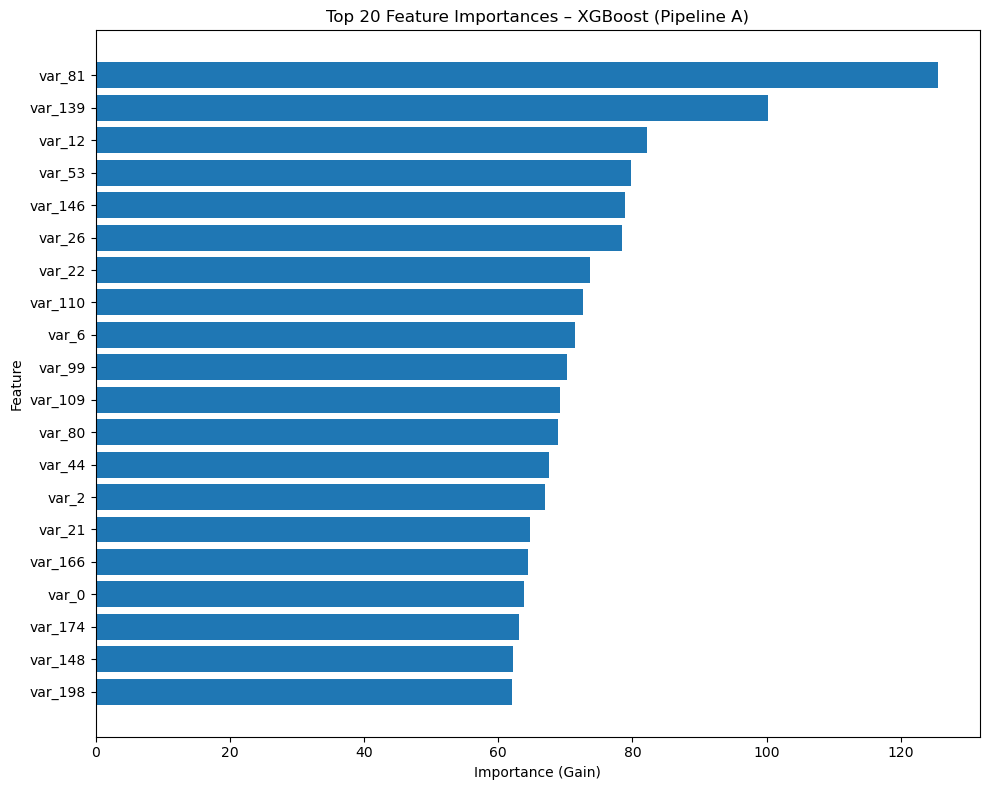

In [37]:
# XGBoost model Pipeline A
print("XGBoost version:", xgb.__version__)

# Pipeline A
# Compute correct class weight from ORIGINAL y_A_train
pos_weight_A = y_A_train.value_counts()[0] / y_A_train.value_counts()[1]
print("Correct scale_pos_weight (Pipeline A):", pos_weight_A)

# XGBoost parameters for Pipeline A
xgb_model_A = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=pos_weight_A,
    random_state=random_seed,
    tree_method='hist',
    eval_metric='auc'
)


# Fit model on Pipeline A selected features
xgb_model_A.fit(
    X_A_train_selected,
    y_A_train,
    eval_set=[(X_A_test_selected, y_A_test)],
    verbose=False
)

print("\nXGBoost Model (Pipeline A) trained successfully.")

# Feature importances (top 20)
# Extract booster (needed for get_score)
booster_A = xgb_model_A.get_booster()
xgb_feature_names_A = booster_A.feature_names

# Get gain-based feature importance from XGBoost
score_dict_A = booster_A.get_score(importance_type='gain')

# Map f0, f1, f2,... → selected feature names
feature_importance_XGB_A = pd.DataFrame({
    "Feature": xgb_feature_names_A,
    "Importance": [score_dict_A.get(i, 0) for i in xgb_feature_names_A]
}).sort_values("Importance", ascending=False)

# Print top 20 features
print("\nTop 20 Important Features – XGBoost (Pipeline A):")
print(feature_importance_XGB_A.head(20))

# Plot top 20 feature importances
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_XGB_A["Feature"].head(20), feature_importance_XGB_A["Importance"].head(20))
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances – XGBoost (Pipeline A)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Correct scale_pos_weight (Pipeline B): 8.962640099626402

XGBoost Model (Pipeline B) trained successfully.

Top 20 Important Features – XGBoost (Pipeline B):
     Feature  Importance
5     var_81  113.803017
1    var_139   99.802315
19    var_12   92.046692
6     var_26   81.095818
33    var_53   80.520645
3    var_146   79.973885
152    var_6   78.524239
55    var_22   77.332008
2    var_110   74.910347
4     var_99   70.786751
29    var_44   70.257133
85     var_2   69.243912
12   var_166   69.141335
0     var_80   68.629135
27   var_109   67.595879
30   var_148   66.306953
53     var_0   65.215126
8    var_190   63.751518
54   var_198   62.434258
10   var_174   61.672424


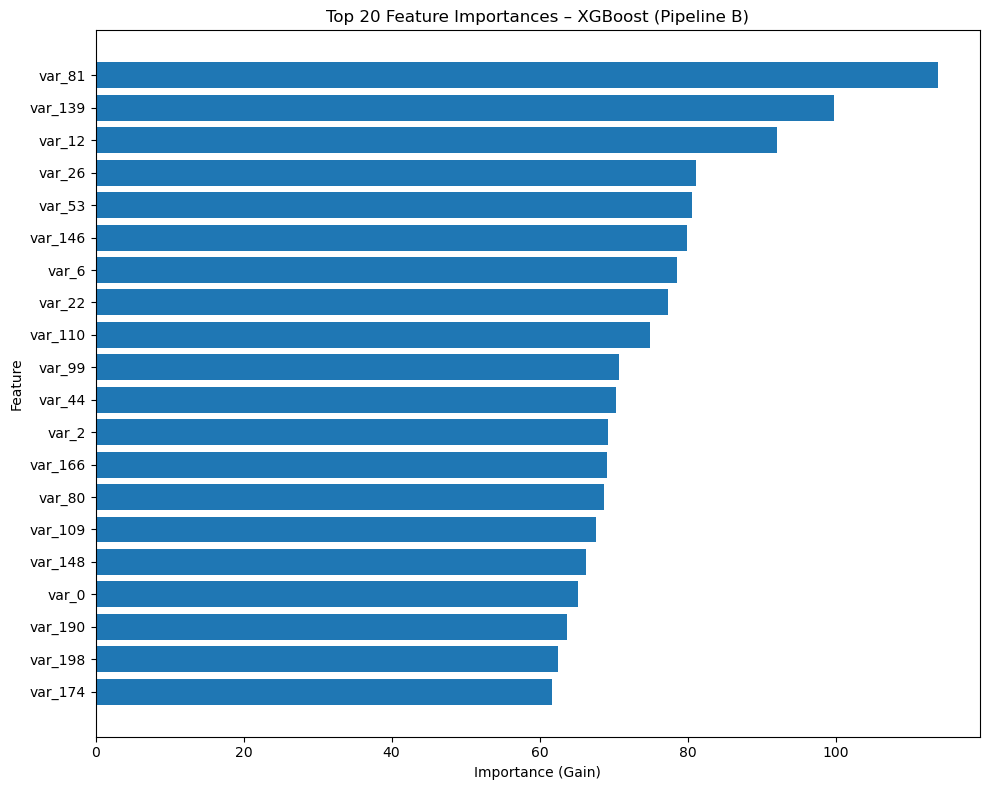

In [38]:
# XGBoost model Pipeline B
# Compute correct class weight from ORIGINAL y_B_train
pos_weight_B = y_B_train.value_counts()[0] / y_B_train.value_counts()[1]
print("Correct scale_pos_weight (Pipeline B):", pos_weight_B)

# XGBoost parameters for Pipeline B
xgb_model_B = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=pos_weight_B,
    random_state=random_seed,
    tree_method='hist',
    eval_metric='auc'
)

# Fit model on Pipeline B selected features
xgb_model_B.fit(
    X_B_train_selected,
    y_B_train,
    eval_set=[(X_B_test_selected, y_B_test)],
    verbose=False
)

print("\nXGBoost Model (Pipeline B) trained successfully.")

# Feature importances (top 20)
# Extract booster (required for get_score)
booster_B = xgb_model_B.get_booster()
xgb_feature_names_B = booster_B.feature_names

# Get gain-based feature importance from XGBoost
score_dict_B = booster_B.get_score(importance_type='gain')

# Map f0, f1, f2,... → selected feature names for Pipeline B
feature_importance_XGB_B = pd.DataFrame({
    "Feature": xgb_feature_names_B,
    "Importance": [score_dict_B.get(i, 0) for i in xgb_feature_names_B]
}).sort_values("Importance", ascending=False)

# Display top 20 important features
print("\nTop 20 Important Features – XGBoost (Pipeline B):")
print(feature_importance_XGB_B.head(20))

# Plot top 20 features
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_XGB_B["Feature"].head(20), feature_importance_XGB_B["Importance"].head(20))
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances – XGBoost (Pipeline B)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Confusion Matrix:
[[16979  1013]
 [ 1001  1007]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     17992
           1       0.50      0.50      0.50      2008

    accuracy                           0.90     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.90      0.90      0.90     20000


Metrics for XGBoost for Pipeline A:
Accuracy: 0.8993
Precision: 0.4985
Recall (Sensitivity): 0.5015
F1-Score: 0.5000


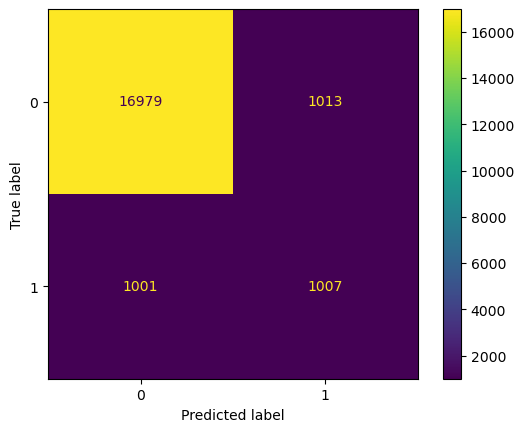

In [99]:
# XGBoost Pipeline A evaluation
# Pipeline A
# Predict classes
prob_XGB_A = xgb_model_A.predict_proba(X_A_test_selected)[:, 1]
prediction_XGB_A = (prob_XGB_A >= 0.5).astype(int)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_A_test, prediction_XGB_A))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_A_test, prediction_XGB_A))

# Calculate specific metrics
accuracy_XGB_A = accuracy_score(y_A_test, prediction_XGB_A)
precision_XGB_A = precision_score(y_A_test, prediction_XGB_A)
recall_XGB_A = recall_score(y_A_test, prediction_XGB_A)
f1_XGB_A = f1_score(y_A_test, prediction_XGB_A)

print(f"\nMetrics for XGBoost for Pipeline A:")
print(f"Accuracy: {accuracy_XGB_A:.4f}")
print(f"Precision: {precision_XGB_A:.4f}")
print(f"Recall (Sensitivity): {recall_XGB_A:.4f}")
print(f"F1-Score: {f1_XGB_A:.4f}")

cm_display_XGB_A = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_A_test, prediction_XGB_A), display_labels = [0, 1])

cm_display_XGB_A.plot()
plt.show()


Confusion Matrix:
[[16898  1094]
 [ 1015   993]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     17992
           1       0.48      0.49      0.48      2008

    accuracy                           0.89     20000
   macro avg       0.71      0.72      0.71     20000
weighted avg       0.90      0.89      0.90     20000


Metrics for XGBoost for Pipeline B:
Accuracy: 0.8945
Precision: 0.4758
Recall (Sensitivity): 0.4945
F1-Score: 0.4850


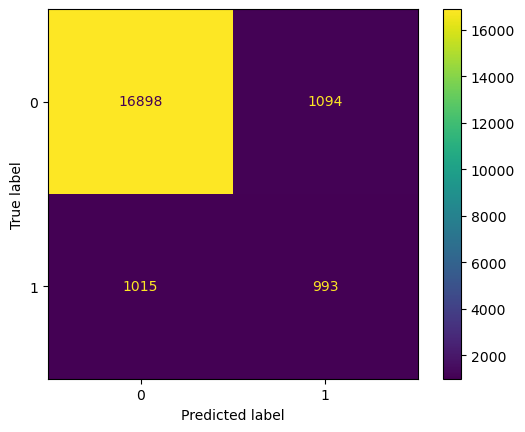

In [100]:
# XGBoost Pipeline B evaluation
# Predict classes
prob_XGB_B = xgb_model_B.predict_proba(X_B_test_selected)[:, 1]
prediction_XGB_B = (prob_XGB_B >= 0.5).astype(int)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_B_test, prediction_XGB_B))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_B_test, prediction_XGB_B))

# Calculate specific metrics
accuracy_XGB_B = accuracy_score(y_B_test, prediction_XGB_B)
precision_XGB_B = precision_score(y_B_test, prediction_XGB_B)
recall_XGB_B = recall_score(y_B_test, prediction_XGB_B)
f1_XGB_B = f1_score(y_B_test, prediction_XGB_B)

print(f"\nMetrics for XGBoost for Pipeline B:")
print(f"Accuracy: {accuracy_XGB_B:.4f}")
print(f"Precision: {precision_XGB_B:.4f}")
print(f"Recall (Sensitivity): {recall_XGB_B:.4f}")
print(f"F1-Score: {f1_XGB_B:.4f}")

cm_display_XGB_B = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_B_test, prediction_XGB_B), display_labels = [0, 1])

cm_display_XGB_B.plot()
plt.show()

XGBoost (Pipeline A) AUC: 0.8605
XGBoost (Pipeline B) AUC: 0.8545


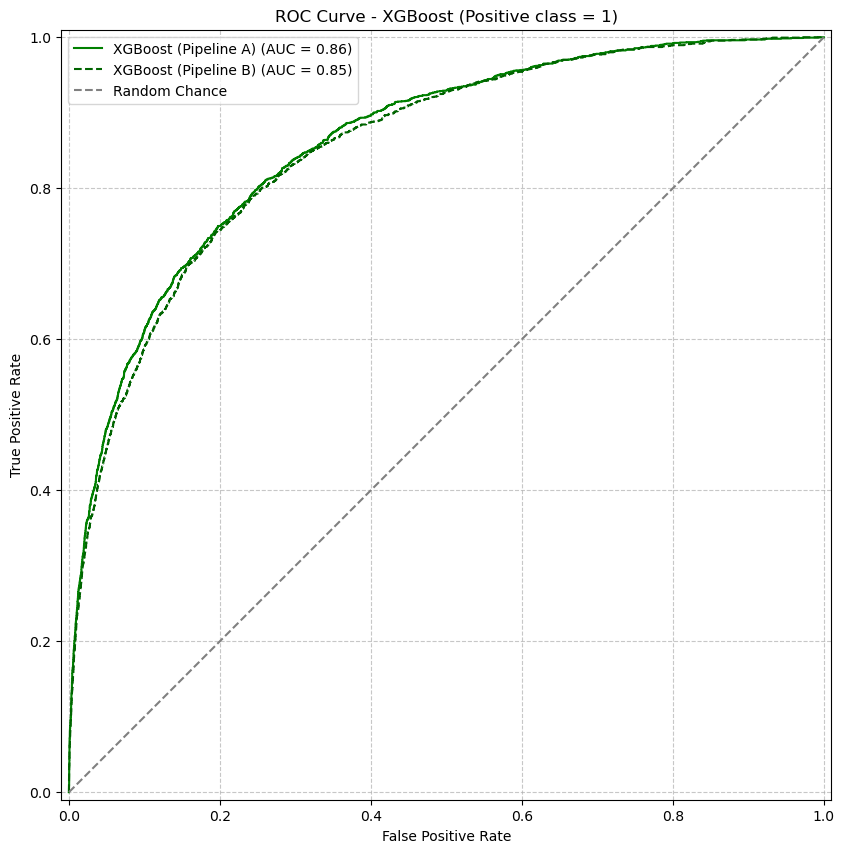

In [41]:
# XGBoost plot ROC curve
fig, ax = plt.subplots(figsize=(10, 10))

auc_XGB_A = roc_auc_score(y_A_test, prob_XGB_A)
print(f"XGBoost (Pipeline A) AUC: {auc_XGB_A:.4f}")
auc_XGB_B = roc_auc_score(y_B_test, prob_XGB_B)
print(f"XGBoost (Pipeline B) AUC: {auc_XGB_B:.4f}")

RocCurveDisplay.from_predictions(y_A_test, prob_XGB_A, name="XGBoost (Pipeline A)", color="green",ax=ax)
RocCurveDisplay.from_predictions(y_B_test, prob_XGB_B, name="XGBoost (Pipeline B)", color="darkgreen", linestyle="--", ax=ax)
ax.plot([0, 1], [0, 1], "--", label="Random Chance", color="grey") # Unmodelled random chance as baseline for comparison
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - XGBoost (Positive class = 1)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.7)


LightGBM Model (Pipeline A) trained successfully.

Top 20 Important Features - LightGBM (Pipeline A):
     Feature  Importance
35    var_22         195
11    var_34         179
86    var_13         169
79     var_6         168
30    var_53         162
8    var_190         162
5     var_12         160
78    var_21         160
10   var_174         146
0     var_80         146
63   var_115         142
85   var_184         141
147    var_1         141
4     var_99         140
61   var_198         140
41    var_40         139
115  var_192         136
47     var_2         133
3     var_81         133
1    var_139         131


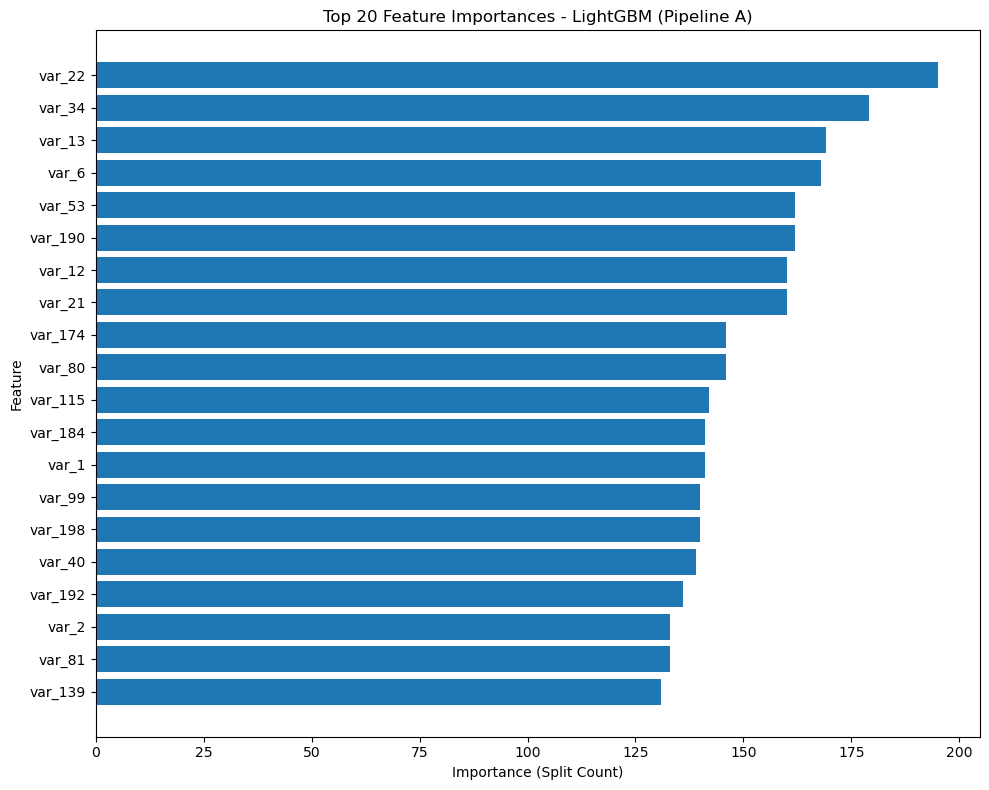

In [42]:
# LightGBM model Pipeline A
# LightGBM parameters
params_A = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'metric': 'auc',

    # Model complexity
    'learning_rate': 0.03,
    'num_leaves': 40,
    'max_depth': 6,
    'min_data_in_leaf': 20,

    # Regularisation
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.2,
    'reg_lambda': 1.0,
    'min_split_gain': 0.05,
    'scale_pos_weight': pos_weight_A,

    'verbosity': -1
}

# Create LightGBM datasets
train_data_A = lgb.Dataset(X_A_train_selected, label=y_A_train)
test_data_A  = lgb.Dataset(X_A_test_selected, label=y_A_test)

# Train model
model_LGBM_A = lgb.train(
    params=params_A,
    train_set=train_data_A,
    num_boost_round=300,
    valid_sets=[train_data_A, test_data_A]
)

print("\nLightGBM Model (Pipeline A) trained successfully.")

# Feature importances (top 20)
feature_importance_LGBM_A = pd.DataFrame({
    "Feature": features_A,
    "Importance": model_LGBM_A.feature_importance(importance_type="split")
}).sort_values("Importance", ascending=False)
print("\nTop 20 Important Features - LightGBM (Pipeline A):")
print(feature_importance_LGBM_A.head(20))

# Plot top 20 feature importances
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_LGBM_A["Feature"].head(20), feature_importance_LGBM_A["Importance"].head(20))
plt.gca().invert_yaxis()
plt.xlabel("Importance (Split Count)")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances - LightGBM (Pipeline A)")
plt.tight_layout()
plt.show()


LightGBM Model (Pipeline B) trained successfully.

Top 20 Important Features - LightGBM (Pipeline B):
     Feature  Importance
55    var_22         172
61    var_13         170
152    var_6         163
80    var_21         163
33    var_53         160
7     var_34         155
8    var_190         152
10   var_174         151
45    var_40         148
71    var_76         146
90   var_184         142
141    var_1         141
4     var_99         139
40    var_67         137
2    var_110         137
3    var_146         136
34   var_170         136
58   var_115         134
54   var_198         133
31   var_154         132


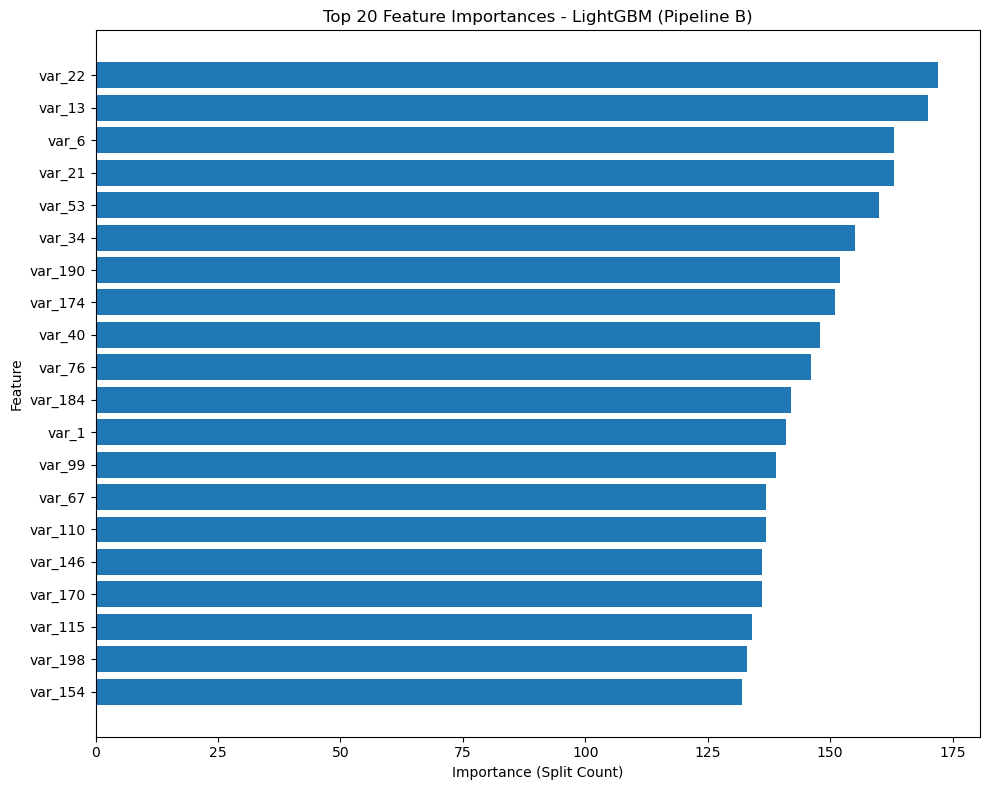

In [43]:
# LightGBM model Pipeline B
# LightGBM parameters
params_B = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'metric': 'auc',

    # Model complexity
    'learning_rate': 0.03,
    'num_leaves': 40,
    'max_depth': 6,
    'min_data_in_leaf': 20,

    # Regularisation
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.2,
    'reg_lambda': 1.0,
    'min_split_gain': 0.05,
    'scale_pos_weight': pos_weight_B,

    'verbosity': -1
}

# Create LightGBM datasets
train_data_B = lgb.Dataset(X_B_train_selected, label=y_B_train)
test_data_B = lgb.Dataset(X_B_test_selected, label=y_B_test)

# Train model
model_LGBM_B = lgb.train(
    params=params_B,
    train_set=train_data_B,
    num_boost_round=300,
    valid_sets=[train_data_B, test_data_B]
)

print("\nLightGBM Model (Pipeline B) trained successfully.")

# Feature importances (top 20)
feature_importance_LGBM_B = pd.DataFrame({
    "Feature": features_B,
    "Importance": model_LGBM_B.feature_importance(importance_type="split")
}).sort_values("Importance", ascending=False)

print("\nTop 20 Important Features - LightGBM (Pipeline B):")
print(feature_importance_LGBM_B.head(20))

# Plot top 20 feature importances
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_LGBM_B["Feature"].head(20), feature_importance_LGBM_B["Importance"].head(20))
plt.gca().invert_yaxis()
plt.xlabel("Importance (Split Count)")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances - LightGBM (Pipeline B)")
plt.tight_layout()
plt.show()

First 10 predictions (Pipeline A):
[0 0 0 0 0 0 1 1 0 1]

Confusion Matrix – LightGBM (Pipeline A):
[[15792  2200]
 [  716  1292]]

Classification Report – LightGBM (Pipeline A):
              precision    recall  f1-score   support

           0       0.96      0.88      0.92     17992
           1       0.37      0.64      0.47      2008

    accuracy                           0.85     20000
   macro avg       0.66      0.76      0.69     20000
weighted avg       0.90      0.85      0.87     20000


Metrics for LightGBM for Pipeline A:
Accuracy: 0.8542
Precision: 0.3700
Recall (Sensitivity): 0.6434
F1-Score: 0.4698


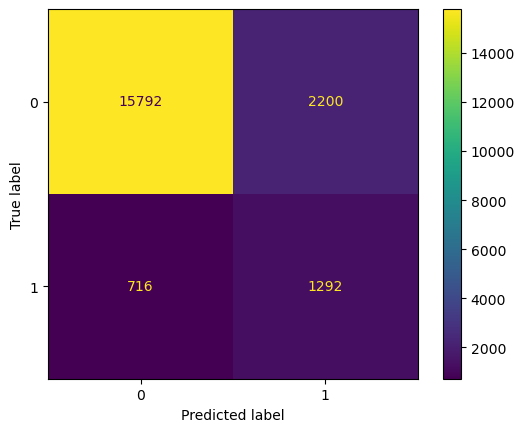

In [101]:
# LightGBM Pipeline A evaluation 
# Predict classes
prob_LGBM_A = model_LGBM_A.predict(X_A_test_selected)
prediction_LGBM_A = (prob_LGBM_A >= 0.5).astype(int)
print("First 10 predictions (Pipeline A):")
print(prediction_LGBM_A[:10])

# Confusion matrix
print("\nConfusion Matrix – LightGBM (Pipeline A):")
print(confusion_matrix(y_A_test, prediction_LGBM_A))

# Classification report
print("\nClassification Report – LightGBM (Pipeline A):")
print(classification_report(y_A_test, prediction_LGBM_A))

# Calculate specific metrics
accuracy_LGBM_A = accuracy_score(y_A_test, prediction_LGBM_A)
precision_LGBM_A = precision_score(y_A_test, prediction_LGBM_A)
recall_LGBM_A = recall_score(y_A_test, prediction_LGBM_A)
f1_LGBM_A = f1_score(y_A_test, prediction_LGBM_A)

print(f"\nMetrics for LightGBM for Pipeline A:")
print(f"Accuracy: {accuracy_LGBM_A:.4f}")
print(f"Precision: {precision_LGBM_A:.4f}")
print(f"Recall (Sensitivity): {recall_LGBM_A:.4f}")
print(f"F1-Score: {f1_LGBM_A:.4f}")

cm_display_LGBM_A = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_A_test, prediction_LGBM_A), display_labels = [0, 1])

cm_display_LGBM_A.plot()
plt.show()

First 10 predictions (Pipeline B):
[0 0 0 0 0 0 1 1 0 1]

Confusion Matrix – LightGBM (Pipeline B):
[[15718  2274]
 [  717  1291]]

Classification Report – LightGBM (Pipeline B):
              precision    recall  f1-score   support

           0       0.96      0.87      0.91     17992
           1       0.36      0.64      0.46      2008

    accuracy                           0.85     20000
   macro avg       0.66      0.76      0.69     20000
weighted avg       0.90      0.85      0.87     20000


Metrics for LightGBM for Pipeline B:
Accuracy: 0.8505
Precision: 0.3621
Recall (Sensitivity): 0.6429
F1-Score: 0.4633


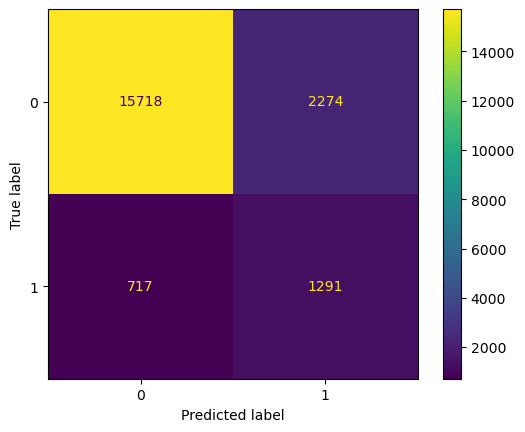

In [102]:
# LightGBM Pipeline B evaluation 
# Predict classes
prob_LGBM_B = model_LGBM_B.predict(X_B_test_selected)
prediction_LGBM_B = (prob_LGBM_B >= 0.5).astype(int)
print("First 10 predictions (Pipeline B):")
print(prediction_LGBM_B[:10])

# Confusion matrix
print("\nConfusion Matrix – LightGBM (Pipeline B):")
print(confusion_matrix(y_B_test, prediction_LGBM_B))

# Classification report
print("\nClassification Report – LightGBM (Pipeline B):")
print(classification_report(y_B_test, prediction_LGBM_B))

# Calculate specific metrics
accuracy_LGBM_B = accuracy_score(y_B_test, prediction_LGBM_B)
precision_LGBM_B = precision_score(y_B_test, prediction_LGBM_B)
recall_LGBM_B = recall_score(y_B_test, prediction_LGBM_B)
f1_LGBM_B = f1_score(y_B_test, prediction_LGBM_B)

print(f"\nMetrics for LightGBM for Pipeline B:")
print(f"Accuracy: {accuracy_LGBM_B:.4f}")
print(f"Precision: {precision_LGBM_B:.4f}")
print(f"Recall (Sensitivity): {recall_LGBM_B:.4f}")
print(f"F1-Score: {f1_LGBM_B:.4f}")

cm_display_LGBM_B = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_B_test, prediction_LGBM_B), display_labels = [0, 1])

cm_display_LGBM_B.plot()
plt.show()

LightGBM (Pipeline A) AUC: 0.8600
LightGBM (Pipeline B) AUC: 0.8577


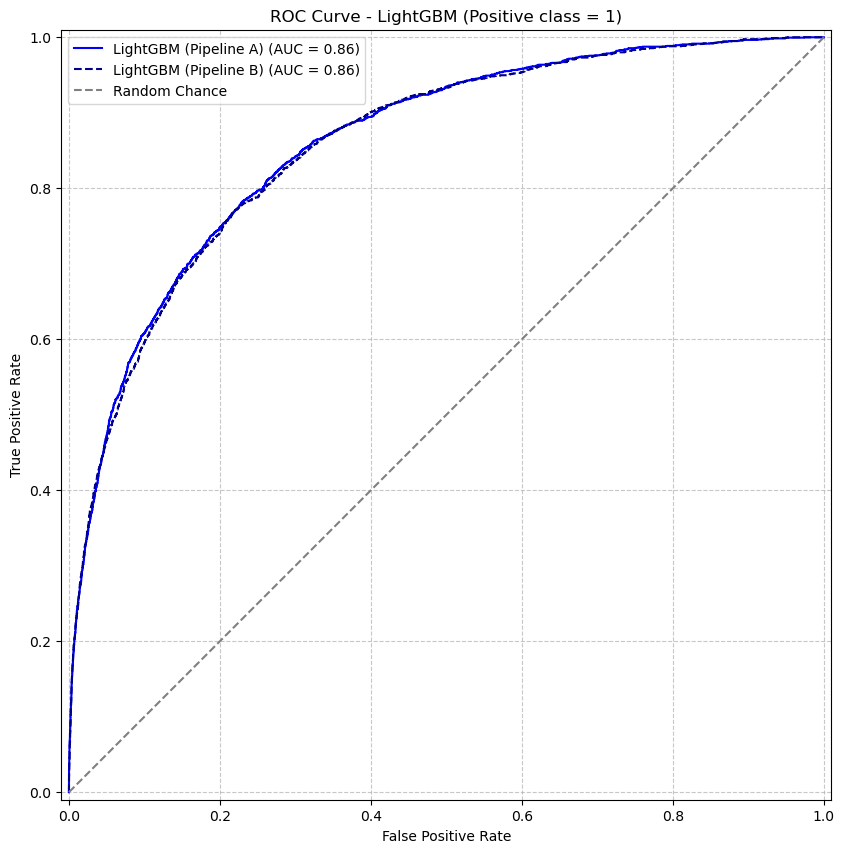

In [46]:
# LightGBM plot ROC curve
fig, ax = plt.subplots(figsize=(10, 10))

auc_LGBM_A = roc_auc_score(y_A_test, prob_LGBM_A)
print(f"LightGBM (Pipeline A) AUC: {auc_LGBM_A:.4f}")
auc_LGBM_B = roc_auc_score(y_B_test, prob_LGBM_B)
print(f"LightGBM (Pipeline B) AUC: {auc_LGBM_B:.4f}")

RocCurveDisplay.from_predictions(y_A_test, prob_LGBM_A, name="LightGBM (Pipeline A)", color="blue",ax=ax)
RocCurveDisplay.from_predictions(y_B_test, prob_LGBM_B, name="LightGBM (Pipeline B)", color="darkblue", linestyle="--", ax=ax)
ax.plot([0, 1], [0, 1], "--", label="Random Chance", color="grey") # Unmodelled random chance as baseline for comparison
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - LightGBM (Positive class = 1)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.7)

In [47]:
# Support Vector Machine (SVM) model
print(f"Due to the computational demand for SVM model training, we are going to use the smaller data set.")

Due to the computational demand for SVM model training, we are going to use the smaller data set.


In [48]:
# Load small data set & prepare data in same way as the full data set
datafile_small = pd.read_csv("datafile_small.csv")


# Pipeline A - drop columns with high-missingness and impute rest with median
datafile_small_A = datafile_small.copy()

# Find columns with more than 10% missing data
high_missing_cols_small = []
for col in datafile_small.columns:
    if col.startswith('var_'):
        missing_pct_small = (datafile_small[col].isnull().sum() / len(datafile_small)) * 100
        if missing_pct_small > 10:
            high_missing_cols_small.append(col)
            print(f"Found: {col} with {missing_pct_small:.1f}% missing")
print(f"\nTotal columns to drop: {len(high_missing_cols_small)}")

# Drop these high-missingness columns from Pipeline A
datafile_small_A = datafile_small_A.drop(columns=high_missing_cols_small)
print(f"Pipeline A shape after dropping: {datafile_small_A.shape}")
print(f"Dropped columns: {high_missing_cols_small}")

# Impute the remaining missing values in Pipeline A with median
for col in datafile_small_A.columns:
    if col.startswith('var_') and datafile_small_A[col].isnull().sum() > 0:
        median_value_small = datafile_small_A[col].median()
        missing_count_small = datafile_small_A[col].isnull().sum()
        datafile_small_A[col] = datafile_small_A[col].fillna(median_value_small)
print(f"\nPipeline A final shape: {datafile_small_A.shape}")
print("All rows retained, only var_45 column was dropped")

# Pipeline B - keep all data and impute with median
datafile_small_B = datafile_small.copy()
print("Impute all missing values with median\n")
for col in datafile_small_B.columns:
    if col.startswith('var_') and datafile_small_B[col].isnull().sum() > 0:
        missing_count_small = datafile_small_B[col].isnull().sum()
        median_value_small = datafile_small_B[col].median()
        datafile_small_B[col] = datafile_small_B[col].fillna(median_value_small)
print(f"\nPipeline B final shape: {datafile_small_B.shape}")
print("All rows retained, all missing values imputed with median")


# Separate features and target for both pipelines
# Pipeline A
X_small_A = datafile_small_A.drop("target", axis=1)
y_small_A = datafile_small_A["target"]
print("Pipeline A:")
print(f"Features: {X_small_A.shape}")
print(f"Target:   {y_small_A.shape}")

# Pipeline B
X_small_B = datafile_small_B.drop("target", axis=1)
y_small_B = datafile_small_B["target"]
print("\nPipeline B:")
print(f"Features: {X_small_B.shape}")
print(f"Target:   {y_small_B.shape}")

Found: var_45 with 40.2% missing

Total columns to drop: 1
Pipeline A shape after dropping: (20000, 201)
Dropped columns: ['var_45']

Pipeline A final shape: (20000, 201)
All rows retained, only var_45 column was dropped
Impute all missing values with median


Pipeline B final shape: (20000, 202)
All rows retained, all missing values imputed with median
Pipeline A:
Features: (20000, 200)
Target:   (20000,)

Pipeline B:
Features: (20000, 201)
Target:   (20000,)


In [49]:
# Partioning train and test data and filter for positive information gain for both pipelines
# Pipeline A
X_small_A_train, X_small_A_test, y_small_A_train, y_small_A_test = train_test_split(
    X_small_A,                      
    y_small_A,                      
    test_size=0.2,            
    random_state=random_seed,
    stratify=y_small_A             
)
print("\nPipeline A split:")
print(f"Train set: {X_small_A_train.shape[0]} rows, {X_small_A_train.shape[1]} features")
print(f"Test set:  {X_small_A_test.shape[0]} rows")
print(f"Train target distribution:")
print(y_small_A_train.value_counts())

# Pipeline B
X_small_B_train, X_small_B_test, y_small_B_train, y_small_B_test = train_test_split(
    X_small_B,
    y_small_B,
    test_size=0.2,
    random_state=random_seed,
    stratify=y_small_B
)
print("\nPipeline B split:")
print(f"Train set: {X_small_B_train.shape[0]} rows, {X_small_B_train.shape[1]} features")
print(f"Test set:  {X_small_B_test.shape[0]} rows")
print(f"Train target distribution:")
print(y_small_B_train.value_counts())


# Filter train and test data for positive information gain for both pipelines
# Apply selection to train and test for both pipelines
X_small_A_train_selected = X_small_A_train[features_A]
X_small_A_test_selected  = X_small_A_test[features_A]
print("\nPipeline A - Final Selected Data Shapes:")
print(f"  Train: {X_small_A_train_selected.shape}")
print(f"  Test:  {X_small_A_test_selected.shape}")

X_small_B_train_selected = X_small_B_train[features_B]
X_small_B_test_selected  = X_small_B_test[features_B]
print("\nPipeline B - Final Selected Data Shapes:")
print(f"  Train: {X_small_B_train_selected.shape}")
print(f"  Test:  {X_small_B_test_selected.shape}")


Pipeline A split:
Train set: 16000 rows, 200 features
Test set:  4000 rows
Train target distribution:
target
0    14429
1     1571
Name: count, dtype: int64

Pipeline B split:
Train set: 16000 rows, 201 features
Test set:  4000 rows
Train target distribution:
target
0    14429
1     1571
Name: count, dtype: int64

Pipeline A - Final Selected Data Shapes:
  Train: (16000, 151)
  Test:  (4000, 151)

Pipeline B - Final Selected Data Shapes:
  Train: (16000, 157)
  Test:  (4000, 157)


In [50]:
# Scaling data for SVM

# Pipeline A
scaler_A = StandardScaler()
X_small_A_train_scaled = pd.DataFrame(
    scaler_A.fit_transform(X_small_A_train_selected),
    columns=X_small_A_train_selected.columns,
    index=X_small_A_train_selected.index)
X_small_A_test_scaled = pd.DataFrame(
    scaler_A.transform(X_small_A_test_selected),
    columns=X_small_A_test_selected.columns,
    index=X_small_A_test_selected.index)

print("\nPipeline A - Scaled Selected Data Shapes:")
print(f"  Train: {X_small_A_train_scaled.shape}")
print(f"  Test:  {X_small_A_test_scaled.shape}")


# Pipeline B
scaler_B = StandardScaler()
X_small_B_train_scaled = pd.DataFrame(
    scaler_B.fit_transform(X_small_B_train_selected),
    columns=X_small_B_train_selected.columns,
    index=X_small_B_train_selected.index)
X_small_B_test_scaled = pd.DataFrame(
    scaler_B.transform(X_small_B_test_selected),
    columns=X_small_B_test_selected.columns,
    index=X_small_B_test_selected.index)

print("\nPipeline B - Scaled Selected Data Shapes:")
print(f"  Train: {X_small_B_train_scaled.shape}")
print(f"  Test:  {X_small_B_test_scaled.shape}")


Pipeline A - Scaled Selected Data Shapes:
  Train: (16000, 151)
  Test:  (4000, 151)

Pipeline B - Scaled Selected Data Shapes:
  Train: (16000, 157)
  Test:  (4000, 157)


In [51]:
# SVM model Pipeline A (linear kernel)
model_SVM_A = SVC(kernel='linear', C = 5.0, class_weight = "balanced", random_state=random_seed, probability=True)

# Fit the model on selected features WITH ORIGINAL labels
model_SVM_A.fit(X_small_A_train_scaled, y_small_A_train)
print("\nSVM Model (Pipeline A) trained successfully.")

# Print model summary
print("SVM Model - Pipeline A (Embedded Balancing)")
print(f"Number of features used: {model_SVM_A.n_features_in_}")
print(f"Training accuracy: {model_SVM_A.score(X_small_A_train_scaled, y_small_A_train):.4f}")


SVM Model (Pipeline A) trained successfully.
SVM Model - Pipeline A (Embedded Balancing)
Number of features used: 151
Training accuracy: 0.7856


In [ ]:
# Feature importances (top 20)
feature_importance_SVM_A = pd.DataFrame({
    'Feature': features_A,
    'Importance': model_SVM_A.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nPipeline A - Top 20 Features (SVM)")
print(feature_importance_SVM_A.head(20))

# Plot top 20 feature importances
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_SVM_A['Feature'].head(20), feature_importance_SVM_A['Importance'].head(20))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances - SVM (Pipeline A)')
plt.gca().invert_yaxis()   # highest importance at top
plt.tight_layout()
plt.show()

In [52]:
# SVM model Pipeline B (linear kernel)
model_SVM_B = SVC(kernel='linear', C = 5.0, class_weight = "balanced", random_state=random_seed, probability=True)

# Fit the model on selected features WITH ORIGINAL labels
model_SVM_B.fit(X_small_B_train_scaled, y_small_B_train)
print("\nSVM Model (Pipeline B) trained successfully.")

# Print model summary
print("SVM Model - Pipeline B (Embedded Balancing)")
print(f"Number of features used: {model_SVM_B.n_features_in_}")
print(f"Training accuracy: {model_SVM_B.score(X_small_B_train_scaled, y_small_B_train):.4f}")


SVM Model (Pipeline B) trained successfully.
SVM Model - Pipeline B (Embedded Balancing)
Number of features used: 157
Training accuracy: 0.7855


In [ ]:
# Feature importances (top 20)
feature_importance_SVM_B = pd.DataFrame({
    'Feature': features_B,
    'Importance': model_SVM_B.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nPipeline B - Top 20 Features (SVM)")
print(feature_importance_SVM_B.head(20))

# Plot top 20 feature importances
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_SVM_B['Feature'].head(20), feature_importance_SVM_B['Importance'].head(20))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances - SVM (Pipeline B)')
plt.gca().invert_yaxis()   # highest importance at top
plt.tight_layout()
plt.show()

First 10 predictions (Pipeline A):
[0 1 0 1 0 0 0 0 0 0]

Confusion Matrix - SVM (Pipeline A):
[[2827  780]
 [ 107  286]]

Classification Report - SVM (Pipeline A):
              precision    recall  f1-score   support

           0       0.96      0.78      0.86      3607
           1       0.27      0.73      0.39       393

    accuracy                           0.78      4000
   macro avg       0.62      0.76      0.63      4000
weighted avg       0.90      0.78      0.82      4000


Metrics for SVM for Pipeline A:
Accuracy: 0.7782
Precision: 0.2683
Recall (Sensitivity): 0.7277
F1-Score: 0.3920


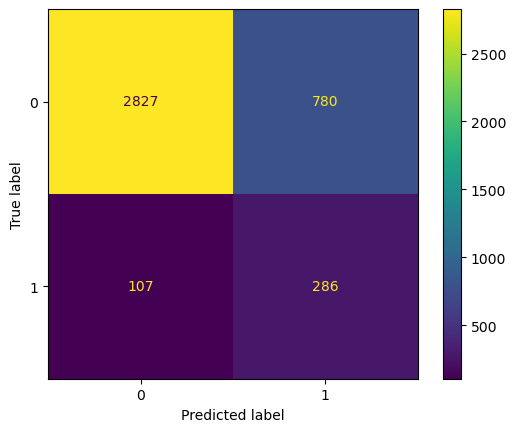

In [103]:
# SVM Pipeline A evaluation
# Predict classes
prediction_SVM_A = model_SVM_A.predict(X_small_A_test_scaled)
print("First 10 predictions (Pipeline A):")
print(prediction_SVM_A[:10])

# Confusion matrix
print("\nConfusion Matrix - SVM (Pipeline A):")
print(confusion_matrix(y_small_A_test, prediction_SVM_A))

# Classification report
print("\nClassification Report - SVM (Pipeline A):")
print(classification_report(y_small_A_test, prediction_SVM_A))

# Calculate specific metrics
accuracy_SVM_A = accuracy_score(y_small_A_test, prediction_SVM_A)
precision_SVM_A = precision_score(y_small_A_test, prediction_SVM_A)
recall_SVM_A = recall_score(y_small_A_test, prediction_SVM_A)
f1_SVM_A = f1_score(y_small_A_test, prediction_SVM_A)

print(f"\nMetrics for SVM for Pipeline A:")
print(f"Accuracy: {accuracy_SVM_A:.4f}")
print(f"Precision: {precision_SVM_A:.4f}")
print(f"Recall (Sensitivity): {recall_SVM_A:.4f}")
print(f"F1-Score: {f1_SVM_A:.4f}")

cm_display_SVM_A = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_small_A_test, prediction_SVM_A), display_labels = [0, 1])

cm_display_SVM_A.plot()
plt.show()

First 10 predictions (Pipeline B):
[0 1 0 1 0 0 0 0 0 0]

Confusion Matrix - SVM (Pipeline B):
[[2836  771]
 [ 110  283]]

Classification Report - SVM (Pipeline B):
              precision    recall  f1-score   support

           0       0.96      0.79      0.87      3607
           1       0.27      0.72      0.39       393

    accuracy                           0.78      4000
   macro avg       0.62      0.75      0.63      4000
weighted avg       0.89      0.78      0.82      4000


Metrics for SVM for Pipeline B:
Accuracy: 0.7798
Precision: 0.2685
Recall (Sensitivity): 0.7201
F1-Score: 0.3912


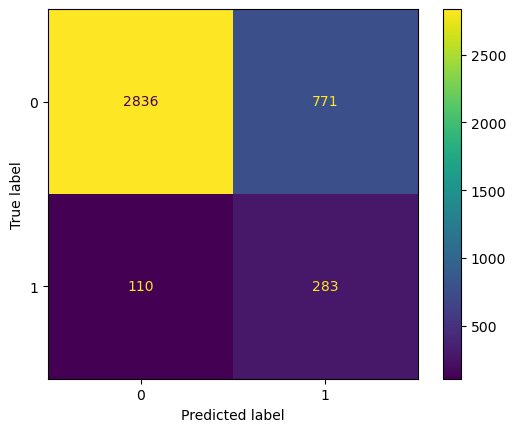

In [104]:
# SVM Pipeline B evaluation
# Predict classes
prediction_SVM_B = model_SVM_B.predict(X_small_B_test_scaled)
print("First 10 predictions (Pipeline B):")
print(prediction_SVM_B[:10])

# Confusion matrix
print("\nConfusion Matrix - SVM (Pipeline B):")
print(confusion_matrix(y_small_B_test, prediction_SVM_B))

# Classification report
print("\nClassification Report - SVM (Pipeline B):")
print(classification_report(y_small_B_test, prediction_SVM_B))

# Calculate specific metrics
accuracy_SVM_B = accuracy_score(y_small_B_test, prediction_SVM_B)
precision_SVM_B = precision_score(y_small_B_test, prediction_SVM_B)
recall_SVM_B = recall_score(y_small_B_test, prediction_SVM_B)
f1_SVM_B = f1_score(y_small_B_test, prediction_SVM_B)

print(f"\nMetrics for SVM for Pipeline B:")
print(f"Accuracy: {accuracy_SVM_B:.4f}")
print(f"Precision: {precision_SVM_B:.4f}")
print(f"Recall (Sensitivity): {recall_SVM_B:.4f}")
print(f"F1-Score: {f1_SVM_B:.4f}")

cm_display_SVM_B = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_small_B_test, prediction_SVM_B), display_labels = [0, 1])

cm_display_SVM_B.plot()
plt.show()

SVM (Pipeline A) AUC: 0.8495
SVM (Pipeline B) AUC: 0.8450


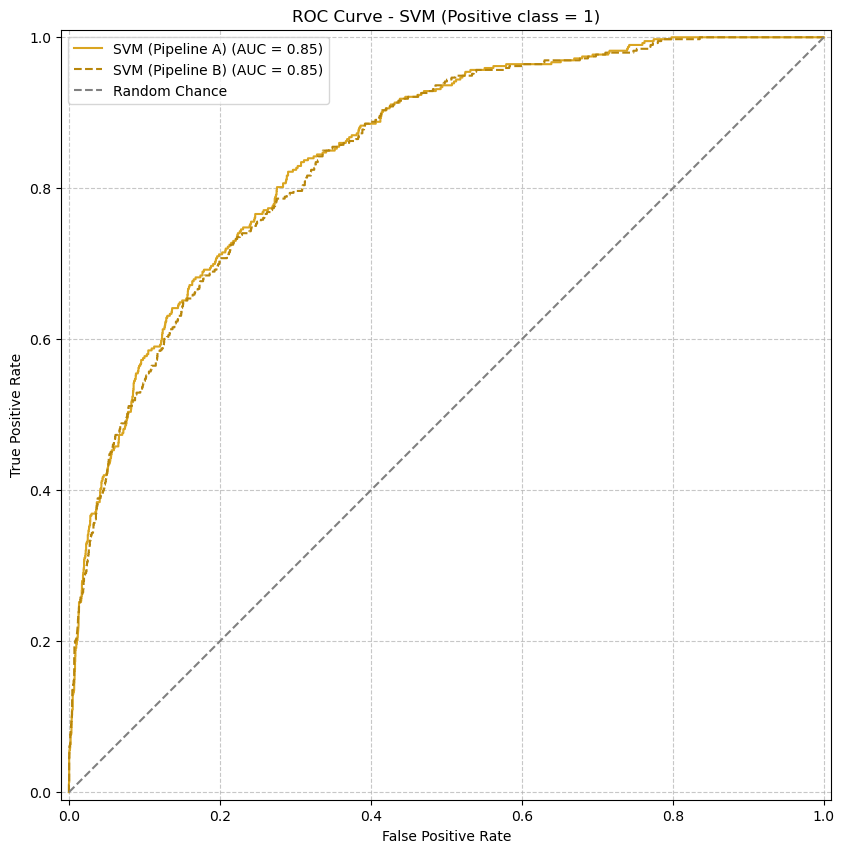

In [55]:
# SVM plot ROC curve
fig, ax = plt.subplots(figsize=(10, 10))

prob_SVM_A = model_SVM_A.predict_proba(X_small_A_test_scaled)[:, 1]
auc_SVM_A = roc_auc_score(y_small_A_test, prob_SVM_A)
print(f"SVM (Pipeline A) AUC: {auc_SVM_A:.4f}")

prob_SVM_B = model_SVM_B.predict_proba(X_small_B_test_scaled)[:, 1]
auc_SVM_B = roc_auc_score(y_small_B_test, prob_SVM_B)
print(f"SVM (Pipeline B) AUC: {auc_SVM_B:.4f}")

RocCurveDisplay.from_predictions(y_small_A_test, prob_SVM_A, name="SVM (Pipeline A)", color="goldenrod",ax=ax)
RocCurveDisplay.from_predictions(y_small_B_test, prob_SVM_B, name="SVM (Pipeline B)", color="darkgoldenrod", linestyle="--", ax=ax)
ax.plot([0, 1], [0, 1], "--", label="Random Chance", color="grey") # Unmodelled random chance as baseline for comparison
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - SVM (Positive class = 1)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.7)

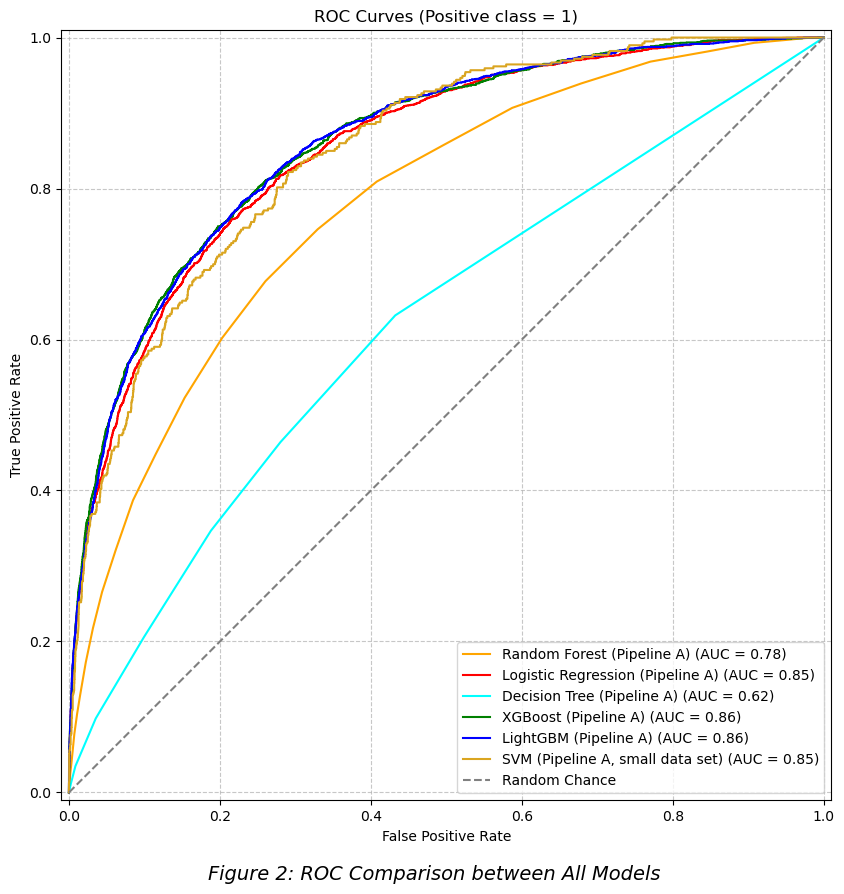

In [167]:
# Plot ROC curves for all models and pipelines
fig, ax = plt.subplots(figsize=(10, 10))
txt = 'Figure 2: ROC Comparison between All Models'
plt.figtext(0.5, 0.03, txt, ha='center', fontsize=14, fontstyle='italic')

# Random Forest
RocCurveDisplay.from_predictions(y_A_test, prob_RF_A, name="Random Forest (Pipeline A)", color="orange",ax=ax)
#RocCurveDisplay.from_predictions(y_B_test, prob_RF_B, name="Random Forest (Pipeline B)", color="darkorange", linestyle="--", ax=ax)

# Logistic Regression
RocCurveDisplay.from_predictions(y_A_test, prob_LR_A, name="Logistic Regression (Pipeline A)", color="red",ax=ax)
#RocCurveDisplay.from_predictions(y_B_test, prob_LR_B, name="Logistic Regression (Pipeline B)", color="darkred", linestyle="--", ax=ax)

# Decision Tree
RocCurveDisplay.from_predictions(y_A_test, prob_DT_A, name="Decision Tree (Pipeline A)", color="cyan",ax=ax)
#RocCurveDisplay.from_predictions(y_B_test, prob_DT_B, name="Decision Tree (Pipeline B)", color="darkcyan", linestyle="--", ax=ax)

# XGBoost
RocCurveDisplay.from_predictions(y_A_test, prob_XGB_A, name="XGBoost (Pipeline A)", color="green",ax=ax)
#RocCurveDisplay.from_predictions(y_B_test, prob_XGB_B, name="XGBoost (Pipeline B)", color="darkgreen", linestyle="--", ax=ax)

# LightGBM
RocCurveDisplay.from_predictions(y_A_test, prob_LGBM_A, name="LightGBM (Pipeline A)", color="blue",ax=ax)
#RocCurveDisplay.from_predictions(y_B_test, prob_LGBM_B, name="LightGBM (Pipeline B)", color="darkblue", linestyle="--", ax=ax)

# SVM
RocCurveDisplay.from_predictions(y_small_A_test, prob_SVM_A, name="SVM (Pipeline A, small data set)", color="goldenrod",ax=ax)
#RocCurveDisplay.from_predictions(y_small_B_test, prob_SVM_B, name="SVM (Pipeline B, small data set)", color="darkgoldenrod", linestyle="--", ax=ax)

# Unmodelled random chance as baseline for comparison
ax.plot([0, 1], [0, 1], "--", label="Random Chance", color="grey")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (Positive class = 1)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.7)

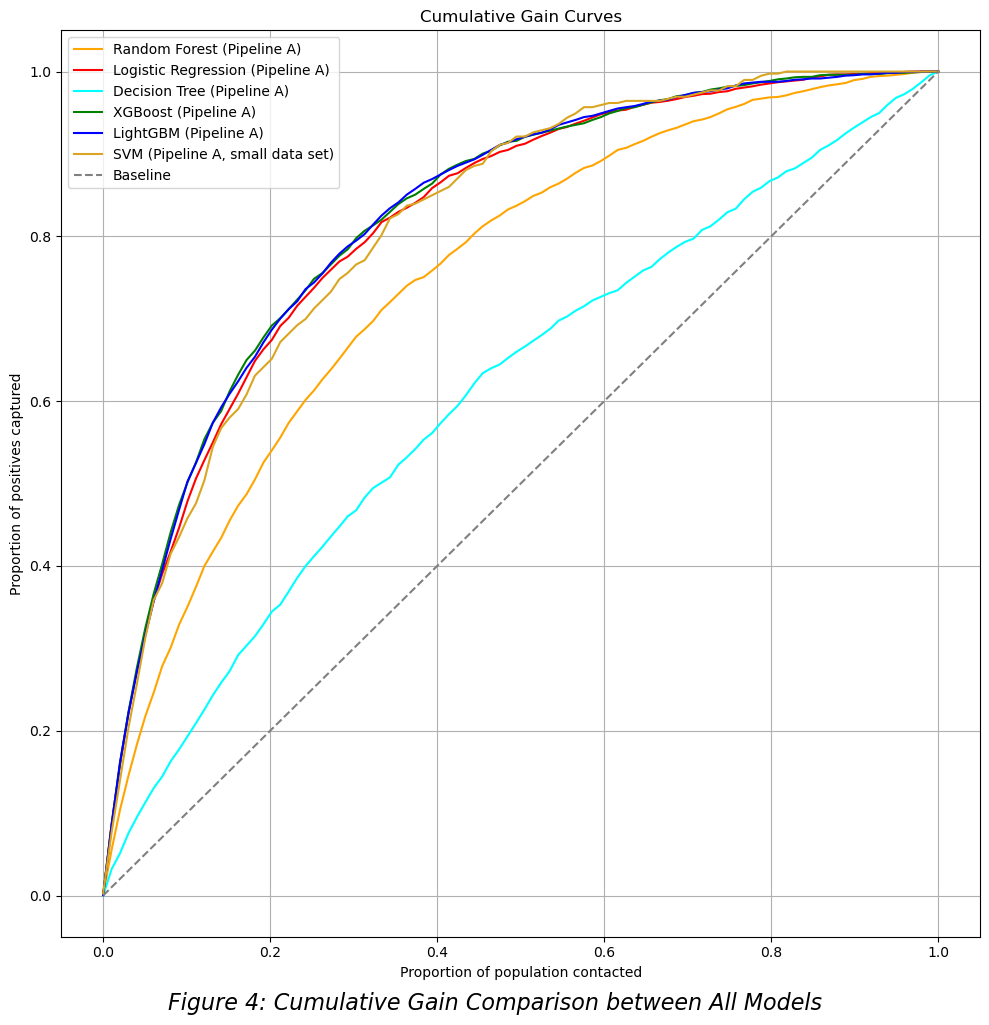

In [184]:
# Plot cumulative gain curves for all models and pipelines

# Define a function to compute the cumulative gain curve
def cumulative_gains(y_true, y_prob, resolution=100):
    # Sort the prediction probs from highest to lowest and store the corresponding indices
    order = np.argsort(y_prob)[::-1]

    # Reorder the true labels (actual target values) so they match the sorted scores
    y_sorted = np.array(y_true)[order]

    # Compute how many positives have been captured
    cum_positives = np.cumsum(y_sorted)

    # Count the total number of positive examples in the dataset
    total_positives = y_sorted.sum()
    
    # Create evenly spaced points between 0 and 1 representing percentages of the population contacted
    perc_population = np.linspace(0, 1, resolution)

    # Convert each population percentage into the corresponding number of individuals
    cutoff = (perc_population * len(y_true)).astype(int)

    # For each cutoff, compute the fraction of all positives has been captured
    gains = cum_positives[np.clip(cutoff - 1, 0, None)] / total_positives
    return perc_population, gains

# Curves

# Random Forest
x_rf_A, g_rf_A = cumulative_gains(y_A_test, prob_RF_A)
#x_rf_B, g_rf_B = cumulative_gains(y_B_test, prob_RF_B)

# Logistical Regression
x_lr_A, g_lr_A = cumulative_gains(y_A_test, prob_LR_A)
#x_lr_B, g_lr_B = cumulative_gains(y_B_test, prob_LR_B)

# Decision Forest
x_dt_A, g_dt_A = cumulative_gains(y_A_test, prob_DT_A)
#x_dt_B, g_dt_B = cumulative_gains(y_B_test, prob_DT_B)

# XGBoost
x_xgb_A, g_xgb_A = cumulative_gains(y_A_test, prob_XGB_A)
#x_xgb_B, g_xgb_B = cumulative_gains(y_B_test, prob_XGB_B)

# LightGBM
x_lgbm_A, g_lgbm_A = cumulative_gains(y_A_test, prob_LGBM_A)
#x_lgbm_B, g_lgbm_B = cumulative_gains(y_B_test, prob_LGBM_B)

# SVM
x_svm_A, g_svm_A = cumulative_gains(y_small_A_test, prob_SVM_A)
#x_svm_B, g_svm_B = cumulative_gains(y_small_B_test, prob_SVM_B)

# Plotting curves
plt.figure(figsize=(10, 10))
txt = 'Figure 4: Cumulative Gain Comparison between All Models'
plt.figtext(0.5, -0.015, txt, ha='center', fontsize=16, fontstyle='italic')

# Random Forest
plt.plot(x_rf_A, g_rf_A, label="Random Forest (Pipeline A)", color="orange")
#plt.plot(x_rf_B, g_rf_B, label="Random Forest (Pipeline B)", color="darkorange", linestyle="--")

# Logistical Regression
plt.plot(x_lr_A, g_lr_A, label="Logistic Regression (Pipeline A)", color="red")
#plt.plot(x_lr_B, g_lr_B, label="Logistic Regression (Pipeline B)", color="darkred", linestyle="--")

# Decision Tree
plt.plot(x_dt_A, g_dt_A, label="Decision Tree (Pipeline A)", color="cyan")
#plt.plot(x_dt_B, g_dt_B, label="Decision Tree (Pipeline B)", color="darkcyan", linestyle="--")

# XGBoost
plt.plot(x_xgb_A, g_xgb_A, label="XGBoost (Pipeline A)", color="green")
#plt.plot(x_xgb_B, g_xgb_B, label="XGBoost (Pipeline B)", color="darkgreen", linestyle="--")

# LightGBM
plt.plot(x_lgbm_A, g_lgbm_A, label="LightGBM (Pipeline A)", color="blue")
#plt.plot(x_lgbm_B, g_lgbm_B, label="LightGBM (Pipeline B)", color="darkblue", linestyle="--")

# SVM
plt.plot(x_svm_A, g_svm_A, label="SVM (Pipeline A, small data set)", color="goldenrod")
#plt.plot(x_svm_B, g_svm_B, label="SVM (Pipeline B, small data set)", color="darkgoldenrod", linestyle="--")

# Baseline
plt.plot([0, 1], [0, 1], '--', label="Baseline", color="grey")

plt.xlabel("Proportion of population contacted")
plt.ylabel("Proportion of positives captured")
plt.title("Cumulative Gain Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

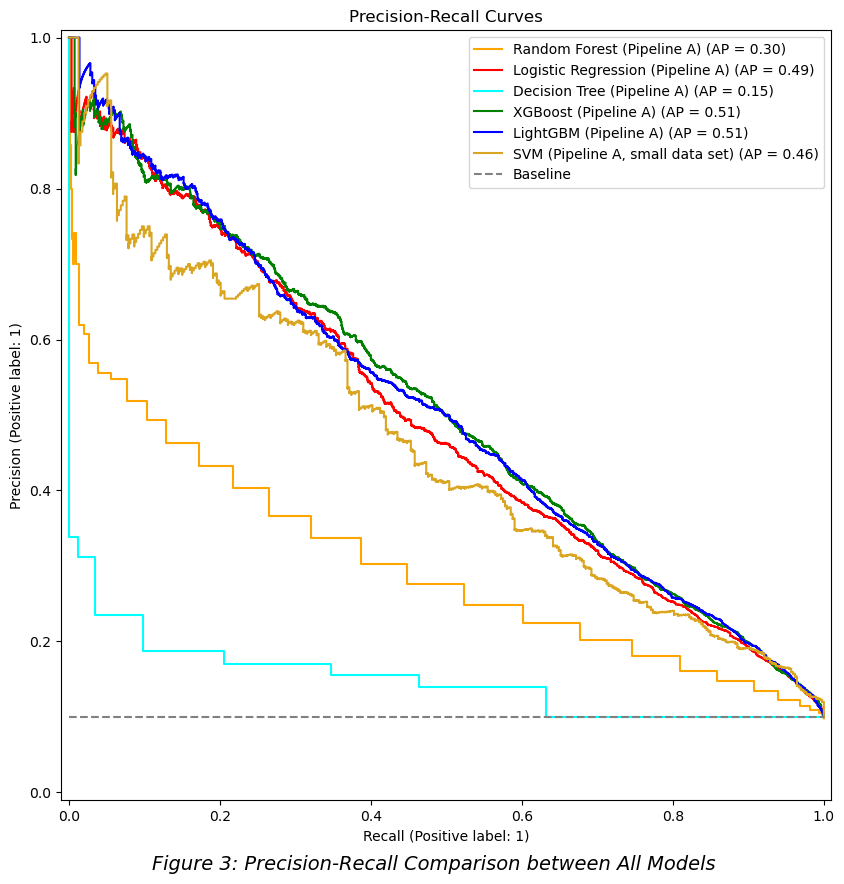

In [168]:
# Plot precision-recall curves for all models and pipelines
fig, ax = plt.subplots(figsize=(10, 10))
txt = 'Figure 3: Precision-Recall Comparison between All Models'
plt.figtext(0.5, 0.04, txt, ha='center', fontsize=14, fontstyle='italic')

# Random Forest
PrecisionRecallDisplay.from_predictions(y_A_test, prob_RF_A, name="Random Forest (Pipeline A)", color="orange",ax=ax)
#PrecisionRecallDisplay.from_predictions(y_B_test, prob_RF_B, name="Random Forest (Pipeline B)", color="darkorange", linestyle="--", ax=ax)

# Logistic Regression
PrecisionRecallDisplay.from_predictions(y_A_test, prob_LR_A, name="Logistic Regression (Pipeline A)", color="red",ax=ax)
#PrecisionRecallDisplay.from_predictions(y_B_test, prob_LR_B, name="Logistic Regression (Pipeline B)", color="darkred", linestyle="--", ax=ax)

# Decision Tree
PrecisionRecallDisplay.from_predictions(y_A_test, prob_DT_A, name="Decision Tree (Pipeline A)", color="cyan",ax=ax)
#PrecisionRecallDisplay.from_predictions(y_B_test, prob_DT_B, name="Decision Tree (Pipeline B)", color="darkcyan", linestyle="--", ax=ax)

# XGBoost
PrecisionRecallDisplay.from_predictions(y_A_test, prob_XGB_A, name="XGBoost (Pipeline A)", color="green",ax=ax)
#PrecisionRecallDisplay.from_predictions(y_B_test, prob_XGB_B, name="XGBoost (Pipeline B)", color="darkgreen", linestyle="--", ax=ax)

# LightGBM
PrecisionRecallDisplay.from_predictions(y_A_test, prob_LGBM_A, name="LightGBM (Pipeline A)", color="blue",ax=ax)
#PrecisionRecallDisplay.from_predictions(y_B_test, prob_LGBM_B, name="LightGBM (Pipeline B)", color="darkblue", linestyle="--", ax=ax)

# SVM
PrecisionRecallDisplay.from_predictions(y_small_A_test, prob_SVM_A, name="SVM (Pipeline A, small data set)", color="goldenrod",ax=ax)
#PrecisionRecallDisplay.from_predictions(y_small_B_test, prob_SVM_B, name="SVM (Pipeline B, small data set)", color="darkgoldenrod", linestyle="--", ax=ax)

# Baseline (positive class prevalence)
baseline = y_A_test.mean()
ax.hlines(baseline, xmin=0, xmax=1, colors='grey', linestyles='--', label="Baseline")

ax.set_title("Precision-Recall Curves")
ax.legend()
plt.show()

In [149]:
# Store all model and pipeline results
comparison_results = []

def add_model_results(model_name, pipeline, y_true, y_pred, y_prob):
    comparison_results.append({
        "Model": model_name,
        "Pipeline": pipeline,
        "AUC": roc_auc_score(y_true, y_prob),
        "Recall (1)": recall_score(y_true, y_pred, pos_label=1),
        "Precision (1)": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1 Score (1)": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred)
    })

# Add results for each model and pipeline
# Random Forest
add_model_results("Random Forest", "A", y_A_test, prediction_RF_A, prob_RF_A)
add_model_results("Random Forest", "B", y_B_test, prediction_RF_B, prob_RF_B)

# Logistic Regression
add_model_results("Logistic Regression", "A", y_A_test, prediction_LR_A, prob_LR_A)
add_model_results("Logistic Regression", "B", y_B_test, prediction_LR_B, prob_LR_B)

# Decision Tree
add_model_results("Decision Tree", "A", y_A_test, prediction_DT_A, prob_DT_A)
add_model_results("Decision Tree", "B", y_B_test, prediction_DT_B, prob_DT_B)

# XGBoost
add_model_results("XGBoost", "A", y_A_test, prediction_XGB_A, prob_XGB_A)
add_model_results("XGBoost", "B", y_B_test, prediction_XGB_B, prob_XGB_B)

# LightGBM
add_model_results("LightGBM", "A", y_A_test, prediction_LGBM_A, prob_LGBM_A)
add_model_results("LightGBM", "B", y_B_test, prediction_LGBM_B, prob_LGBM_B)

# SVM
add_model_results("SVM (small data set)", "A", y_small_A_test, prediction_SVM_A, prob_SVM_A)
add_model_results("SVM (small data set)", "B", y_small_B_test, prediction_SVM_B, prob_SVM_B)

# Create DataFrame
comparison_df = pd.DataFrame(comparison_results)

# Sort by AUC descending
comparison_df = comparison_df.sort_values("AUC", ascending=False).reset_index(drop=True)

comparison_df

,Model,Pipeline,AUC,Recall (1),Precision (1),F1 Score (1),Accuracy
0,XGBoost,A,0.860508,0.501494,0.498515,0.500000,0.89930
1,LightGBM,A,0.859974,0.643426,0.369989,0.469818,0.85420
2,LightGBM,B,0.857679,0.642928,0.362132,0.463305,0.85045
3,Logistic Regression,B,0.854575,0.770418,0.270786,0.400725,0.76865
4,XGBoost,B,0.854514,0.494522,0.475803,0.484982,0.89455
5,Logistic Regression,A,0.853629,0.771414,0.271993,0.402181,0.76975
6,SVM (small data set),A,0.849527,0.727735,0.268293,0.392049,0.77825
7,SVM (small data set),B,0.845026,0.720102,0.268501,0.391154,0.77975
8,Random Forest,A,0.778865,0.000000,0.000000,0.000000,0.89960
9,Random Forest,B,0.773150,0.000000,0.000000,0.000000,0.89960


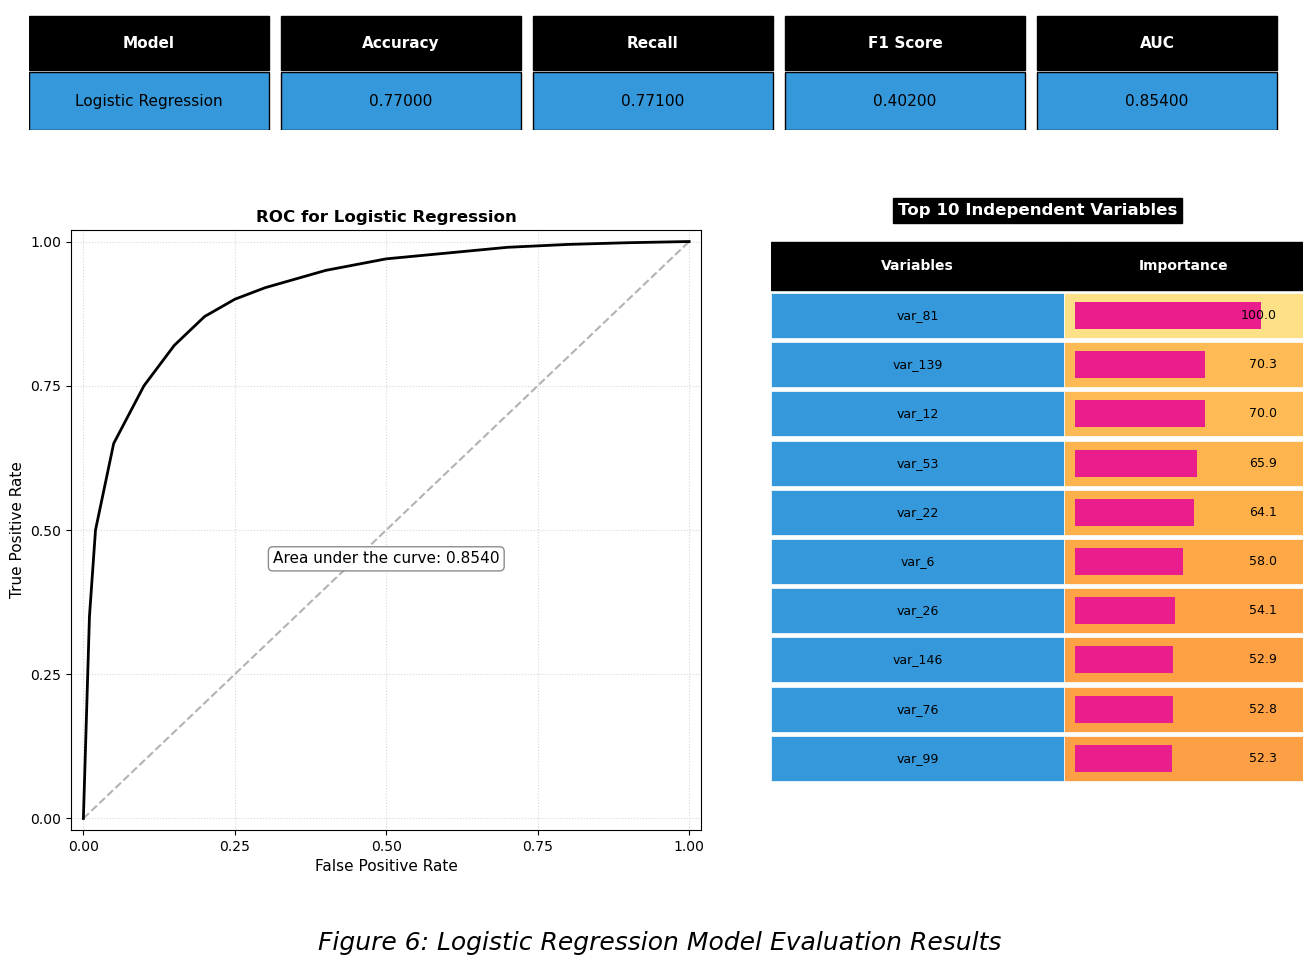

In [188]:
accuracy = 0.770
recall = 0.771
f1 = 0.402 
auc = 0.854  # Replace with your actual AUC
 
# Top 10 features - UPDATE THESE
features = ['var_81', 'var_139', 'var_12', 'var_53', 'var_22', 
            'var_6', 'var_26', 'var_146', 'var_76', 'var_99']
importance = [0.009090, 0.006389, 0.006364, 0.005991, 0.005827,
              0.005273, 0.004915, 0.004810, 0.004802, 0.004758]
# Normalize importance to 0-100 scale
max_imp = max(importance)
importance_scaled = [round((x / max_imp) * 100, 1) for x in importance]
 
# ========== CREATE VISUALIZATION ==========
fig = plt.figure(figsize=(14, 10))
 
# ========== TOP TABLE ==========
ax_table = fig.add_axes([0.05, 0.85, 0.9, 0.12])
ax_table.axis('off')
 
table_data = [
    ['Model', 'Accuracy', 'Recall', 'F1 Score', 'AUC'],
    ['Logistic Regression', f'{accuracy:.5f}', f'{recall:.5f}', f'{f1:.5f}', f'{auc:.5f}']
]
 
# Header row
for i, text in enumerate(table_data[0]):
    rect = FancyBboxPatch((i * 0.2, 0.5), 0.19, 0.45, boxstyle="square,pad=0", 
                          facecolor='#000000', edgecolor='black', linewidth=1)
    ax_table.add_patch(rect)
    ax_table.text(i * 0.2 + 0.095, 0.72, text, ha='center', va='center', 
                  fontsize=11, color='white', fontweight='bold')
 
# Data row
for i, text in enumerate(table_data[1]):
    rect = FancyBboxPatch((i * 0.2, 0.0), 0.19, 0.48, boxstyle="square,pad=0", 
                          facecolor='#3498db', edgecolor='black', linewidth=1)
    ax_table.add_patch(rect)
    ax_table.text(i * 0.2 + 0.095, 0.24, text, ha='center', va='center', 
                  fontsize=11, color='black')
 
ax_table.set_xlim(0, 1)
ax_table.set_ylim(0, 1)
 
# ========== ROC CURVE ==========
ax_roc = fig.add_axes([0.08, 0.15, 0.45, 0.60])
 
# Simulated ROC curve - replace with your actual fpr, tpr if available
fpr = np.array([0, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
tpr = np.array([0, 0.35, 0.50, 0.65, 0.75, 0.82, 0.87, 0.90, 0.92, 0.95, 0.97, 0.98, 0.99, 0.995, 0.998, 1.0])
 
ax_roc.plot(fpr, tpr, 'k-', linewidth=2)
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3)
 
ax_roc.set_xticks([0, 0.25, 0.50, 0.75, 1.00])
ax_roc.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
ax_roc.grid(True, linestyle=':', alpha=0.5)
 
ax_roc.set_xlabel('False Positive Rate', fontsize=11)
ax_roc.set_ylabel('True Positive Rate', fontsize=11)
ax_roc.set_title('ROC for Logistic Regression', fontsize=12, fontweight='bold')
 
ax_roc.text(0.5, 0.45, f'Area under the curve: {auc:.4f}', 
            ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9))
 
ax_roc.set_xlim(-0.02, 1.02)
ax_roc.set_ylim(-0.02, 1.02)
# ========== FEATURE IMPORTANCE TABLE ==========
ax_feat = fig.add_axes([0.58, 0.15, 0.38, 0.60])
ax_feat.axis('off')
 
ax_feat.text(0.5, 1.02, 'Top 10 Independent Variables', ha='center', va='bottom',
             fontsize=12, fontweight='bold', 
             bbox=dict(boxstyle='square,pad=0.3', facecolor='#000000', edgecolor='black'),
             color='white')
 
# Header row
ax_feat.add_patch(FancyBboxPatch((0, 0.90), 0.55, 0.08, boxstyle="square,pad=0",
                                  facecolor='#000000', edgecolor='black'))
ax_feat.text(0.275, 0.94, 'Variables', ha='center', va='center', fontsize=10, color='white', fontweight='bold')
 
ax_feat.add_patch(FancyBboxPatch((0.55, 0.90), 0.45, 0.08, boxstyle="square,pad=0",
                                  facecolor='#000000', edgecolor='black'))
ax_feat.text(0.775, 0.94, 'Importance', ha='center', va='center', fontsize=10, color='white', fontweight='bold')
 
# Data rows
for i, (feat, imp) in enumerate(zip(features, importance_scaled)):
    y_pos = 0.82 - i * 0.082
    bg_color = plt.cm.YlOrRd(0.2 + 0.5 * (1 - imp/100))
    ax_feat.add_patch(FancyBboxPatch((0, y_pos), 0.55, 0.075, boxstyle="square,pad=0",
                                      facecolor='#3498db', edgecolor='white', linewidth=0.5))
    ax_feat.text(0.275, y_pos + 0.0375, feat, ha='center', va='center', fontsize=9, color='black')
    ax_feat.add_patch(FancyBboxPatch((0.55, y_pos), 0.45, 0.075, boxstyle="square,pad=0",
                                      facecolor=bg_color, edgecolor='white', linewidth=0.5))
    bar_width = 0.35 * (imp / 100)
    ax_feat.add_patch(FancyBboxPatch((0.57, y_pos + 0.015), bar_width, 0.045, boxstyle="square,pad=0",
                                      facecolor='#e91e8c', edgecolor='none'))
    ax_feat.text(0.95, y_pos + 0.0375, f'{imp}', ha='right', va='center', fontsize=9, color='black')
 
ax_feat.set_xlim(0, 1)
ax_feat.set_ylim(0, 1)
 
#Figure caption
fig.text(0.5, 0.03, 'Figure 6: Logistic Regression Model Evaluation Results', 
        ha='center', fontsize=18, fontstyle='italic')
 
plt.savefig('Figure2_LogReg_Model_Stats.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()